# Clustering joueurs - agrégation quantitative des features

Objectif : créer des features claires en regroupant quantitativement les attributs très corrélés, avant de lancer le clustering des joueurs.


## 1. Setup


In [337]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

PROJECT_ROOT = Path.cwd()
SCHEMA = "public"

# Une distance de 0.25 correspond grossièrement à une corrélation absolue de 0.75.
FEATURE_DISTANCE_THRESHOLD = 0.25
MIN_AVG_CORRELATION_TO_AGGREGATE = 0.75
PROFILE_CORRELATION_THRESHOLD = 0.75
MANUALLY_EXCLUDED_PROFILE_FEATURES = ["weight_kg"]
CLUSTERING_FEATURE_MODE = "style"

RANDOM_STATE = 42
K_RANGE = range(2, 11)
MIN_PLAYERS_BY_ROLE = 30
PROFILE_ZSCORE_THRESHOLD = 0.40
SMALL_CLUSTER_SHARE_THRESHOLD = 0.05


## 2. Connexion Neon


In [338]:
def load_env_file(path: Path) -> dict[str, str]:
    values = {}

    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()

        if not line or line.startswith("#") or "=" not in line:
            continue

        key, value = line.split("=", 1)
        values[key.strip()] = value.strip().strip('"').strip("'")

    return values


def sqlalchemy_url(url: str) -> str:
    if url.startswith("postgres://"):
        return url.replace("postgres://", "postgresql+psycopg2://", 1)

    if url.startswith("postgresql://"):
        return url.replace("postgresql://", "postgresql+psycopg2://", 1)

    return url


env_path = PROJECT_ROOT / ".env"
if not env_path.exists():
    raise FileNotFoundError("Fichier .env introuvable à la racine du projet.")

local_env = load_env_file(env_path)
DATABASE_URL = (
    os.environ.get("NEON_DATABASE_URL")
    or os.environ.get("DATABASE_URL")
    or os.environ.get("POSTGRES_URL")
    or local_env.get("NEON_DATABASE_URL")
    or local_env.get("DATABASE_URL")
    or local_env.get("POSTGRES_URL")
    or ""
)

if not DATABASE_URL:
    raise RuntimeError("Ajoute NEON_DATABASE_URL, DATABASE_URL ou POSTGRES_URL dans .env.")

engine = create_engine(sqlalchemy_url(DATABASE_URL), pool_pre_ping=True)
print("Connexion configurée")


Connexion configurée


## 3. Charger les joueurs


In [339]:
players_df = pd.read_sql(
    f'''
    SELECT *
    FROM "{SCHEMA}"."player"
    ''',
    engine,
)

print(f"Joueurs chargés : {len(players_df):,}".replace(",", " "))
print(f"Colonnes disponibles : {len(players_df.columns)}")
display(players_df.head())


Joueurs chargés : 6 705
Colonnes disponibles : 101


,player_id,player_name,full_name,sofifa_name,player_aliases,date_of_birth,nationality,height_cm,weight_kg,preferred_foot,observed_positions,positions,best_position,club_name,club_league_name,club_position,sofifa_id,has_sofifa_profile,lineup_rows,match_count,team_count,first_match_date,last_match_date,transfermarkt_market_value_eur,transfermarkt_highest_market_value_eur,best_overall,overall_rating,potential,sofifa_market_value_raw,sofifa_wage_raw,skill_moves,weak_foot,international_reputation,body_type,real_face,sofifa_release_clause_raw,acceleration_type,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,fk_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,attack_position,vision,penalties,composure,defensive_awareness,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,pos_ls_rating,pos_st_rating,pos_rs_rating,pos_lw_rating,pos_lf_rating,pos_cf_rating,pos_rf_rating,pos_rw_rating,pos_lam_rating,pos_cam_rating,pos_ram_rating,pos_lm_rating,pos_lcm_rating,pos_cm_rating,pos_rcm_rating,pos_rm_rating,pos_lwb_rating,pos_ldm_rating,pos_cdm_rating,pos_rdm_rating,pos_rwb_rating,pos_lb_rating,pos_lcb_rating,pos_cb_rating,pos_rcb_rating,pos_rb_rating,pos_gk_rating,player_specialities_json,roles_json,playstyles_json
0,889193,AZ Jackson,Aziel Christopher Jackson,Aziel Jackson,AZ Jackson,2001-10-25,United States,175.0,68.0,Right,Left Winger,"CAM,CM,ST",CAM,Jagiellonia Białystok,Ekstraklasa,SUB,262094.0,1,6,6,1,2025-09-24,2025-12-18,NaN,NaN,66.0,64.0,71.0,€1.2M,€3K,3.0,3.0,1.0,Normal (170-185),No,€1.9M,Explosive,52.0,58.0,35.0,65.0,56.0,74.0,40.0,30.0,58.0,65.0,80.0,78.0,86.0,53.0,82.0,64.0,57.0,36.0,58.0,45.0,49.0,30.0,60.0,62.0,56.0,64.0,29.0,40.0,32.0,6.0,12.0,8.0,14.0,6.0,60.0,60.0,60.0,65.0,63.0,63.0,63.0,65.0,64.0,64.0,64.0,63.0,57.0,57.0,57.0,63.0,49.0,48.0,48.0,48.0,49.0,47.0,42.0,42.0,42.0,47.0,14.0,[],"[{""focus"": ""Attack"", ""name"": ""Shadow striker +...",[]
1,1122196,Aaron Bibout,None,None,Aaron Bibout,2004-09-09,Cameroon,193.0,NaN,None,Centre-Forward,None,None,KRC Genk,None,None,NaN,0,15,15,1,2025-08-28,2026-03-19,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None
2,434207,Aaron Connolly,Aaron Anthony Connolly,Aaron Connolly,Aaron Connolly,2000-01-28,Republic of Ireland,175.0,73.0,Right,"Centre-Forward,Left Winger","ST,LM,CAM,LW",ST,Leyton Orient,League One,CAM,237286.0,1,4,4,1,2021-09-19,2021-10-23,3500000.0,7000000.0,70.0,68.0,72.0,€1.7M,€2K,3.0,3.0,1.0,Normal (170-185),Yes,€3.1M,Controlled explosive,54.0,69.0,65.0,63.0,68.0,68.0,62.0,43.0,45.0,68.0,77.0,73.0,78.0,68.0,78.0,70.0,75.0,67.0,62.0,68.0,68.0,21.0,70.0,58.0,60.0,63.0,25.0,23.0,20.0,12.0,8.0,12.0,13.0,12.0,68.0,68.0,68.0,67.0,68.0,68.0,68.0,67.0,66.0,66.0,66.0,65.0,58.0,58.0,58.0,65.0,49.0,46.0,46.0,46.0,49.0,46.0,43.0,43.0,43.0,46.0,18.0,[],"[{""focus"": ""Attack Support Versatile"", ""name"":...",[]
3,92571,Aaron Cresswell,Aaron William Cresswell,Aaron Cresswell,Aaron Cresswell,1989-12-15,England,175.0,66.0,Left,"Left-Back,Centre-Back","LB,CB,LM",LB,Stoke City,Championship,LB,189615.0,1,97,97,1,2021-08-15,2025-05-18,450000.0,12000000.0,72.0,72.0,72.0,€725K,€18K,2.0,3.0,1.0,Normal (170-185),Yes,€1.4M,Controlled,79.0,53.0,70.0,75.0,48.0,70.0,78.0,74.0,67.0,74.0,52.0,48.0,63.0,72.0,65.0,70.0,74.0,56.0,63.0,66.0,73.0,74.0,60.0,68.0,59.0,71.0,75.0,76.0,75.0,14.0,7.0,9.0,9.0,12.0,64.0,64.0,64.0,66.0,66.0,66.0,66.0,66.0,67.0,67.0,67.0,67.0,69.0,69.0,69.0,67.0,70.0,72.0,72.0,72.0,70.0,70.0,72.0,72.0,72.0,70.0,17.0,[],"[{""focus"": ""Defend Balanced Versatile"", ""name""...",[]
4,591949,Aaron Hickey,Aaron Buchanan Hickey,Aaron Hickey,Aaron 

## 4. Définir les postes et les features

Pour faire des moyennes propres, on sépare les notes 0-100 des variables de profil comme `height_cm`, `weight_kg`, `skill_moves` ou `weak_foot`.


In [340]:
POSITION_GROUPS = {
    "Gardien": ["GK"],
    "Défenseur": ["CB", "LB", "RB", "LWB", "RWB"],
    "Milieu": ["CDM", "CM", "CAM", "LM", "RM"],
    "Attaquant": ["ST", "CF", "LW", "RW"],
}

position_to_group = {
    position: group
    for group, positions in POSITION_GROUPS.items()
    for position in positions
}

position_to_role = {
    "GK": "goalkeeper",
    "CB": "central_defender",
    "LB": "fullback_wingback",
    "RB": "fullback_wingback",
    "LWB": "fullback_wingback",
    "RWB": "fullback_wingback",
    "CDM": "defensive_midfielder",
    "CM": "central_midfielder",
    "CAM": "attacking_midfielder",
    "LM": "wide_player",
    "RM": "wide_player",
    "LW": "wide_player",
    "RW": "wide_player",
    "ST": "forward",
    "CF": "forward",
}

ROLE_GROUPS = {
    role: sorted([position for position, mapped_role in position_to_role.items() if mapped_role == role])
    for role in sorted(set(position_to_role.values()))
}

# Notes joueurs de champ, toutes sur une échelle comparable 0-100.
outfield_rating_attributes = [
    "crossing", "finishing", "heading_accuracy", "short_passing", "volleys", "dribbling",
    "curve", "fk_accuracy", "long_passing", "ball_control", "acceleration", "sprint_speed",
    "agility", "reactions", "balance", "shot_power", "jumping", "stamina", "strength",
    "long_shots", "aggression", "interceptions", "attack_position", "vision", "penalties",
    "composure", "defensive_awareness", "standing_tackle", "sliding_tackle",
]

# Variables utiles mais pas à moyenner avec des notes 0-100.
outfield_profile_attributes = ["skill_moves", "weak_foot", "height_cm", "weight_kg"]

# Notes gardien + style gardien, en 0-100.
goalkeeper_rating_attributes = [
    "gk_diving", "gk_handling", "gk_kicking", "gk_positioning", "gk_reflexes",
    "reactions", "composure", "jumping", "strength", "stamina", "aggression",
    "short_passing", "long_passing", "vision", "ball_control", "shot_power",
    "acceleration", "sprint_speed", "agility", "balance",
]

goalkeeper_profile_attributes = ["weak_foot", "height_cm", "weight_kg"]

field_attribute_set = outfield_rating_attributes + outfield_profile_attributes
goalkeeper_attribute_set = goalkeeper_rating_attributes + goalkeeper_profile_attributes

attributes_by_position = {
    position: (goalkeeper_attribute_set if position == "GK" else field_attribute_set)
    for positions in POSITION_GROUPS.values()
    for position in positions
}

all_feature_columns = sorted(set(field_attribute_set + goalkeeper_attribute_set))
required_columns = ["player_id", "best_position"] + all_feature_columns
missing_columns = [column for column in required_columns if column not in players_df.columns]

if missing_columns:
    raise KeyError(f"Colonnes absentes de players_df: {missing_columns}")

print("Notes joueurs de champ:", len(outfield_rating_attributes))
print("Notes gardiens:", len(goalkeeper_rating_attributes))


Notes joueurs de champ: 29
Notes gardiens: 20


In [341]:
# Colonnes numériques utiles pour décrire un joueur.
# On évite les colonnes de valeur, overall, potentiel et les JSON.
feature_columns = [
    "height_cm",
    "weight_kg",
    "skill_moves",
    "weak_foot",
    "international_reputation",
    "crossing",
    "finishing",
    "heading_accuracy",
    "short_passing",
    "volleys",
    "dribbling",
    "curve",
    "fk_accuracy",
    "long_passing",
    "ball_control",
    "acceleration",
    "sprint_speed",
    "agility",
    "reactions",
    "balance",
    "shot_power",
    "jumping",
    "stamina",
    "strength",
    "long_shots",
    "aggression",
    "interceptions",
    "attack_position",
    "vision",
    "penalties",
    "composure",
    "defensive_awareness",
    "standing_tackle",
    "sliding_tackle",
    "gk_diving",
    "gk_handling",
    "gk_kicking",
    "gk_positioning",
    "gk_reflexes",
]

base_columns = ["player_id", "best_position"]
missing_columns = [column for column in base_columns + feature_columns if column not in players_df.columns]

if missing_columns:
    raise KeyError(f"Colonnes absentes: {missing_columns}")

players_clustering_df = players_df[base_columns + feature_columns].copy()

for column in feature_columns:
    players_clustering_df[column] = pd.to_numeric(players_clustering_df[column], errors="coerce")

# On garde les joueurs qui ont au moins quelques vraies caractéristiques SoFIFA.
players_clustering_df = players_clustering_df.dropna(subset=feature_columns, how="all").reset_index(drop=True)

print(players_clustering_df.shape)
display(players_clustering_df.head())
players_clustering_df["best_position"].unique()

(6330, 41)


,player_id,best_position,height_cm,weight_kg,skill_moves,weak_foot,international_reputation,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,fk_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,attack_position,vision,penalties,composure,defensive_awareness,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,889193,CAM,175.0,68.0,3.0,3.0,1.0,52.0,58.0,35.0,65.0,56.0,74.0,40.0,30.0,58.0,65.0,80.0,78.0,86.0,53.0,82.0,64.0,57.0,36.0,58.0,45.0,49.0,30.0,60.0,62.0,56.0,64.0,29.0,40.0,32.0,6.0,12.0,8.0,14.0,6.0
1,1122196,None,193.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,434207,ST,175.0,73.0,3.0,3.0,1.0,54.0,69.0,65.0,63.0,68.0,68.0,62.0,43.0,45.0,68.0,77.0,73.0,78.0,68.0,78.0,70.0,75.0,67.0,62.0,68.0,68.0,21.0,70.0,58.0,60.0,63.0,25.0,23.0,20.0,12.0,8.0,12.0,13.0,12.0
3,92571,LB,175.0,66.0,2.0,3.0,1.0,79.0,53.0,70.0,75.0,48.0,70.0,78.0,74.0,67.0,74.0,52.0,48.0,63.0,72.0,65.0,70.0,74.0,56.0,63.0,66.0,73.0,74.0,60.0,68.0,59.0,71.0,75.0,76.0,75.0,14.0,7.0,9.0,9.0,12.0
4,591949,RB,185.0,72.0,2.0,5.0,1.0,74.0,48.0,67.0,75.0,67.0,74.0,61.0,40.0,68.0,74.0,70.0,72.0,71.0,73.0,64.0,68.0,69.0,60.0,59.0,60.0,78.0,72.0,59.0,67.0,47.0,72.0,75.0,76.0,75.0,13.0,14.0,8.0,13.0,5.0


array(['CAM', None, 'ST', 'LB', 'RB', 'CM', 'GK', 'CB', 'LW', 'RM', 'CDM',
       'LM', 'CF', 'RW', 'LWB', 'RWB'], dtype=object)

## 5. Nettoyer les lignes utilisables

On garde uniquement les joueurs qui ont toutes les features nécessaires à leur poste.


In [342]:
players_features_df = players_df[["player_id", "best_position"] + all_feature_columns].copy()
players_features_df["position_group"] = players_features_df["best_position"].map(position_to_group)

for column in all_feature_columns:
    players_features_df[column] = pd.to_numeric(players_features_df[column], errors="coerce")


def count_missing_required_features(row):
    required_attributes = attributes_by_position.get(row["best_position"], [])

    if not required_attributes:
        return None

    return int(row[required_attributes].isna().sum())


players_features_df["missing_required_count"] = players_features_df.apply(
    count_missing_required_features,
    axis=1,
)

players_complete_df = (
    players_features_df[
        players_features_df["position_group"].notna()
        & players_features_df["missing_required_count"].eq(0)
    ]
    .drop_duplicates(subset="player_id")
    .reset_index(drop=True)
)

field_players_df = players_complete_df[players_complete_df["best_position"] != "GK"].copy()
goalkeepers_df = players_complete_df[players_complete_df["best_position"] == "GK"].copy()

print(f"Joueurs conservés : {len(players_complete_df):,}".replace(",", " "))
print(f"Joueurs de champ : {len(field_players_df):,}".replace(",", " "))
print(f"Gardiens : {len(goalkeepers_df):,}".replace(",", " "))


Joueurs conservés : 5 023
Joueurs de champ : 4 518
Gardiens : 505


## 6. Fonctions d'agrégation par corrélation

Méthode :

1. calculer les corrélations entre features ;
2. transformer la corrélation en distance : `distance = 1 - abs(correlation)` ;
3. faire un clustering hiérarchique des colonnes ;
4. agréger les groupes cohérents par moyenne.


In [343]:
def get_correlation_matrix(frame, columns):
    # On retire les colonnes constantes, car elles ne peuvent pas être corrélées.
    usable_columns = [
        column
        for column in columns
        if column in frame.columns and frame[column].nunique(dropna=True) > 1
    ]

    return frame[usable_columns].corr().fillna(0)


def get_feature_linkage(correlation_df):
    # Distance faible = features très corrélées.
    distance_df = 1 - correlation_df.abs()
    distance_array = distance_df.to_numpy(copy=True)
    np.fill_diagonal(distance_array, 0)

    condensed_distance = squareform(distance_array, checks=False)
    return linkage(condensed_distance, method="average")


def plot_feature_dendrogram(correlation_df, title):
    linkage_matrix = get_feature_linkage(correlation_df)

    fig = plt.figure(figsize=(14, 6))
    dendrogram(
        linkage_matrix,
        labels=correlation_df.columns.tolist(),
        leaf_rotation=90,
    )
    plt.axhline(FEATURE_DISTANCE_THRESHOLD, color="red", linestyle="--")
    plt.title(title)
    plt.ylabel("distance = 1 - abs(correlation)")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def score_feature_group(correlation_df, features):
    # Score simple : moyenne des corrélations internes + part expliquée par le premier axe.
    if len(features) == 1:
        return {
            "avg_abs_correlation": np.nan,
            "min_abs_correlation": np.nan,
            "first_axis_share": 1.0,
        }

    group_corr_df = correlation_df.loc[features, features]
    upper_mask = np.triu(np.ones(group_corr_df.shape), k=1).astype(bool)
    correlations = group_corr_df.abs().where(upper_mask).stack()

    eigenvalues = np.linalg.eigvalsh(group_corr_df)
    eigenvalues = np.clip(eigenvalues, 0, None)
    first_axis_share = eigenvalues.max() / eigenvalues.sum()

    return {
        "avg_abs_correlation": round(correlations.mean(), 3),
        "min_abs_correlation": round(correlations.min(), 3),
        "first_axis_share": round(first_axis_share, 3),
    }


def build_feature_groups(frame, columns, group_prefix):
    correlation_df = get_correlation_matrix(frame, columns)
    linkage_matrix = get_feature_linkage(correlation_df)
    group_ids = fcluster(
        linkage_matrix,
        t=FEATURE_DISTANCE_THRESHOLD,
        criterion="distance",
    )

    feature_groups_df = pd.DataFrame({
        "feature": correlation_df.columns,
        "group_id": group_ids,
    }).sort_values(["group_id", "feature"])

    rows = []
    for group_id, group_df in feature_groups_df.groupby("group_id"):
        features = group_df["feature"].tolist()
        scores = score_feature_group(correlation_df, features)
        should_aggregate = (
            len(features) > 1
            and scores["avg_abs_correlation"] >= MIN_AVG_CORRELATION_TO_AGGREGATE
        )

        rows.append({
            "group_id": group_id,
            "feature_count": len(features),
            "should_aggregate": should_aggregate,
            "aggregated_feature": f"{group_prefix}_grp_{group_id:02d}",
            "features": features,
            **scores,
        })

    group_summary_df = (
        pd.DataFrame(rows)
        .sort_values(["should_aggregate", "feature_count", "avg_abs_correlation"], ascending=[False, False, False])
        .reset_index(drop=True)
    )

    return correlation_df, feature_groups_df, group_summary_df


def create_aggregated_dataset(frame, group_summary_df, profile_columns):
    result_df = frame[["player_id", "best_position", "position_group"] + profile_columns].copy()
    mapping_rows = []

    for _, row in group_summary_df.iterrows():
        features = row["features"]

        if row["should_aggregate"]:
            new_column = row["aggregated_feature"]
            result_df[new_column] = frame[features].mean(axis=1).round(1)
            mapping_rows.append({
                "output_feature": new_column,
                "source_type": "mean_aggregated",
                "source_features": features,
            })
        else:
            # Si le groupe n'est pas assez cohérent, on garde les features séparées.
            for feature in features:
                result_df[feature] = frame[feature]
                mapping_rows.append({
                    "output_feature": feature,
                    "source_type": "kept_raw",
                    "source_features": [feature],
                })

    return result_df, pd.DataFrame(mapping_rows)


## 7. Groupes corrélés - joueurs de champ


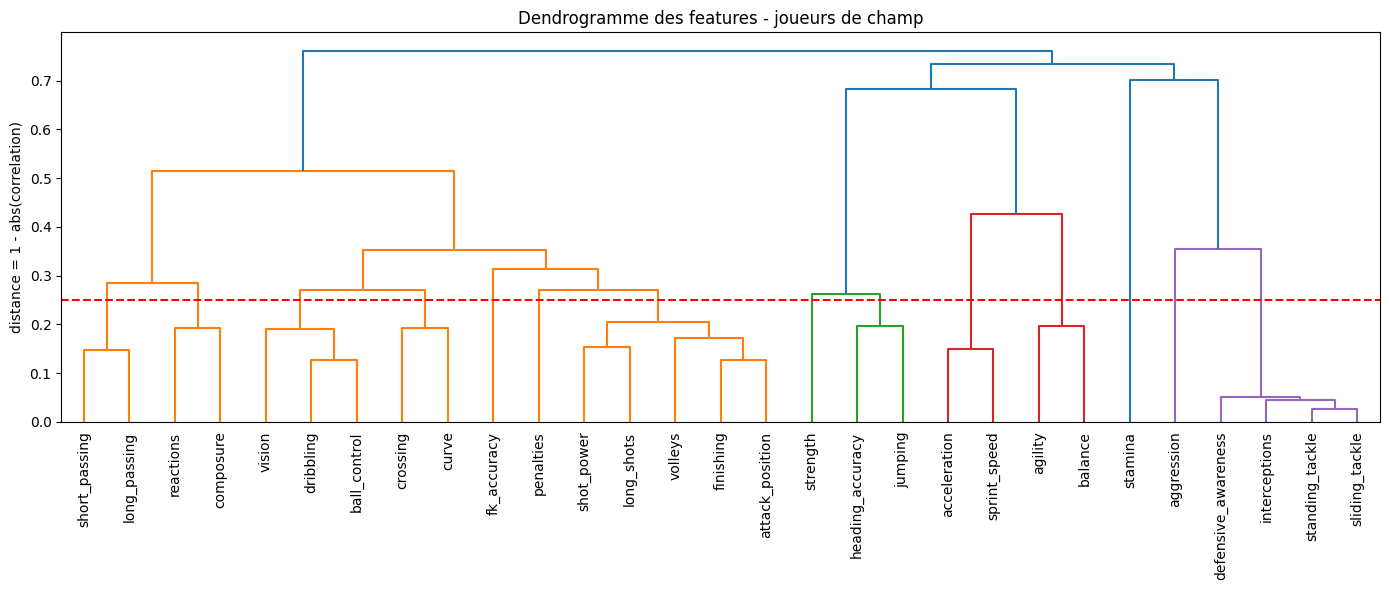

,group_id,feature_count,should_aggregate,aggregated_feature,features,avg_abs_correlation,min_abs_correlation,first_axis_share
0,5,5,True,field_grp_05,"[attack_position, finishing, long_shots, shot_...",0.814,0.728,0.852
1,12,4,True,field_grp_12,"[defensive_awareness, interceptions, sliding_t...",0.955,0.946,0.966
2,3,3,True,field_grp_03,"[ball_control, dribbling, vision]",0.831,0.803,0.887
3,1,2,True,field_grp_01,"[long_passing, short_passing]",0.853,0.853,0.926
4,10,2,True,field_grp_10,"[acceleration, sprint_speed]",0.850,0.850,0.925
5,2,2,True,field_grp_02,"[composure, reactions]",0.808,0.808,0.904
6,4,2,True,field_grp_04,"[crossing, curve]",0.808,0.808,0.904
7,8,2,True,field_grp_08,"[heading_accuracy, jumping]",0.804,0.804,0.902
8,11,2,True,field_grp_11,"[agility, balance]",0.803,0.803,0.902
9,6,1,False,field_grp_06,[penalties],NaN,NaN,1.000


In [344]:
field_corr_df, field_feature_groups_df, field_group_summary_df = build_feature_groups(
    field_players_df,
    outfield_rating_attributes,
    group_prefix="field",
)

plot_feature_dendrogram(field_corr_df, "Dendrogramme des features - joueurs de champ")
display(field_group_summary_df)


## 8. Groupes corrélés - gardiens


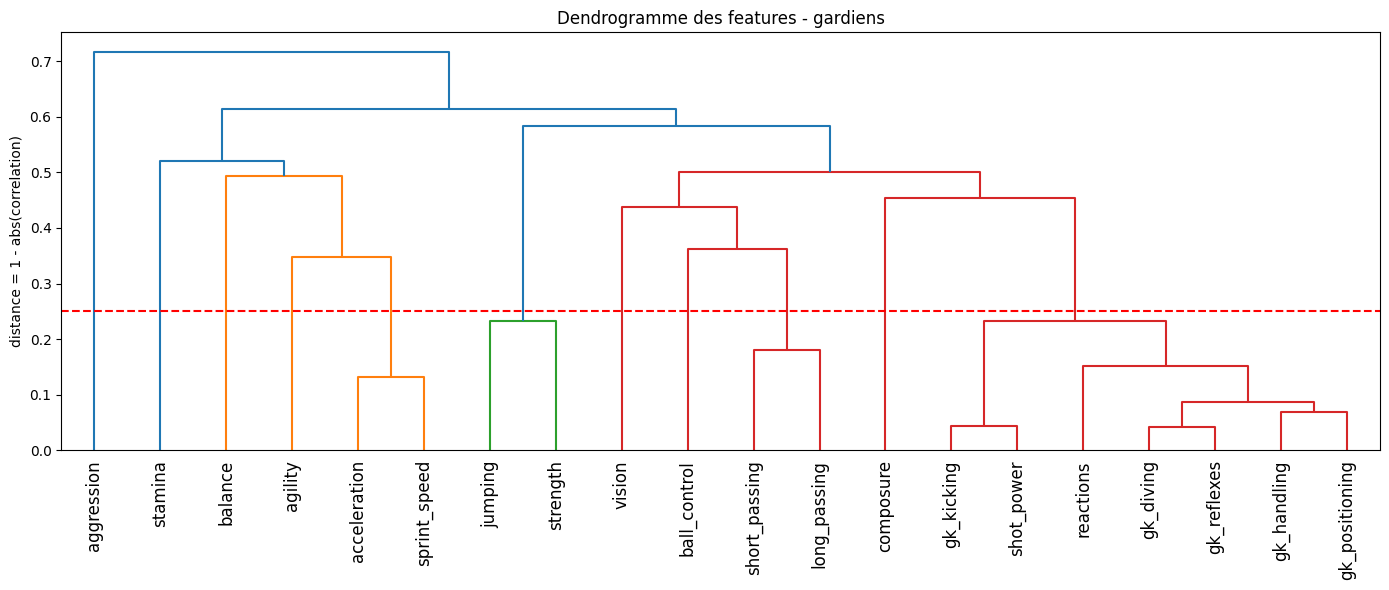

,group_id,feature_count,should_aggregate,aggregated_feature,features,avg_abs_correlation,min_abs_correlation,first_axis_share
0,9,7,True,gk_grp_09,"[gk_diving, gk_handling, gk_kicking, gk_positi...",0.837,0.702,0.861
1,1,2,True,gk_grp_01,"[acceleration, sprint_speed]",0.868,0.868,0.934
2,6,2,True,gk_grp_06,"[long_passing, short_passing]",0.820,0.820,0.910
3,5,2,True,gk_grp_05,"[jumping, strength]",0.767,0.767,0.883
4,2,1,False,gk_grp_02,[agility],NaN,NaN,1.000
5,3,1,False,gk_grp_03,[balance],NaN,NaN,1.000
6,4,1,False,gk_grp_04,[stamina],NaN,NaN,1.000
7,7,1,False,gk_grp_07,[ball_control],NaN,NaN,1.000
8,8,1,False,gk_grp_08,[vision],NaN,NaN,1.000
9,10,1,False,gk_grp_10,[composure],NaN,NaN,1.000


In [345]:
gk_corr_df, gk_feature_groups_df, gk_group_summary_df = build_feature_groups(
    goalkeepers_df,
    goalkeeper_rating_attributes,
    group_prefix="gk",
)

plot_feature_dendrogram(gk_corr_df, "Dendrogramme des features - gardiens")
display(gk_group_summary_df)


## 9. Créer les datasets agrégés

Les groupes cohérents sont moyennés. Les features non agrégées restent telles quelles.


In [346]:
field_aggregated_df, field_aggregation_mapping_df = create_aggregated_dataset(
    field_players_df,
    field_group_summary_df,
    profile_columns=outfield_profile_attributes,
)

gk_aggregated_df, gk_aggregation_mapping_df = create_aggregated_dataset(
    goalkeepers_df,
    gk_group_summary_df,
    profile_columns=goalkeeper_profile_attributes,
)

players_aggregated_features_df = pd.concat(
    [field_aggregated_df, gk_aggregated_df],
    ignore_index=True,
    sort=False,
)

players_aggregated_features_df["position_role"] = players_aggregated_features_df["best_position"].map(position_to_role)
role_players_aggregated_features_df = players_aggregated_features_df[
    players_aggregated_features_df["position_role"].notna()
].copy()

aggregation_summary_df = pd.DataFrame([
    {
        "player_type": "field",
        "raw_rating_features": len(outfield_rating_attributes),
        "final_features_with_profile": field_aggregated_df.shape[1] - 3,
    },
    {
        "player_type": "goalkeeper",
        "raw_rating_features": len(goalkeeper_rating_attributes),
        "final_features_with_profile": gk_aggregated_df.shape[1] - 3,
    },
])

print("Mapping joueurs de champ")
display(field_aggregation_mapping_df)

print("Mapping gardiens")
display(gk_aggregation_mapping_df)

display(aggregation_summary_df)
display(players_aggregated_features_df.head())


Mapping joueurs de champ


,output_feature,source_type,source_features
0,field_grp_05,mean_aggregated,"[attack_position, finishing, long_shots, shot_..."
1,field_grp_12,mean_aggregated,"[defensive_awareness, interceptions, sliding_t..."
2,field_grp_03,mean_aggregated,"[ball_control, dribbling, vision]"
3,field_grp_01,mean_aggregated,"[long_passing, short_passing]"
4,field_grp_10,mean_aggregated,"[acceleration, sprint_speed]"
5,field_grp_02,mean_aggregated,"[composure, reactions]"
6,field_grp_04,mean_aggregated,"[crossing, curve]"
7,field_grp_08,mean_aggregated,"[heading_accuracy, jumping]"
8,field_grp_11,mean_aggregated,"[agility, balance]"
9,penalties,kept_raw,[penalties]


Mapping gardiens


,output_feature,source_type,source_features
0,gk_grp_09,mean_aggregated,"[gk_diving, gk_handling, gk_kicking, gk_positi..."
1,gk_grp_01,mean_aggregated,"[acceleration, sprint_speed]"
2,gk_grp_06,mean_aggregated,"[long_passing, short_passing]"
3,gk_grp_05,mean_aggregated,"[jumping, strength]"
4,agility,kept_raw,[agility]
5,balance,kept_raw,[balance]
6,stamina,kept_raw,[stamina]
7,ball_control,kept_raw,[ball_control]
8,vision,kept_raw,[vision]
9,composure,kept_raw,[composure]


,player_type,raw_rating_features,final_features_with_profile
0,field,29,18
1,goalkeeper,20,14


,player_id,best_position,position_group,skill_moves,weak_foot,height_cm,weight_kg,field_grp_05,field_grp_12,field_grp_03,field_grp_01,field_grp_10,field_grp_02,field_grp_04,field_grp_08,field_grp_11,penalties,fk_accuracy,strength,aggression,stamina,gk_grp_09,gk_grp_01,gk_grp_06,gk_grp_05,agility,balance,ball_control,vision,composure,position_role
0,889193,CAM,Milieu,3.0,3.0,175.0,68.0,56.6,32.8,67.0,61.5,79.0,58.5,46.0,46.0,84.0,56.0,30.0,58.0,49.0,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,attacking_midfielder
1,434207,ST,Attaquant,3.0,3.0,175.0,73.0,69.0,22.2,64.7,54.0,75.0,65.5,58.0,70.0,78.0,60.0,43.0,62.0,68.0,67.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,forward
2,92571,LB,Défenseur,2.0,3.0,175.0,66.0,59.4,75.0,70.7,71.0,50.0,71.5,78.5,72.0,64.0,59.0,74.0,63.0,73.0,56.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fullback_wingback
3,591949,RB,Défenseur,2.0,5.0,185.0,72.0,60.4,74.5,71.7,71.5,71.0,72.5,67.5,68.0,67.5,47.0,40.0,59.0,78.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fullback_wingback
4,123951,CM,Milieu,3.0,3.0,174.0,68.0,71.4,70.5,73.3,78.5,60.0,76.0,73.0,61.0,72.5,73.0,71.0,74.0,74.0,76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,central_midfielder


## 10. Contrôler les corrélations après agrégation

On vérifie que les features finales sont moins redondantes qu'avant.


Contrôle des variables de profil


,player_type,profile_feature,most_correlated_rating_feature,max_abs_correlation_to_rating,manual_exclusion,keep_for_kmeans,drop_reason
0,field,skill_moves,field_grp_03,0.663,False,True,None
1,field,weak_foot,field_grp_05,0.302,False,True,None
2,field,height_cm,field_grp_11,0.770,False,False,high_correlation
3,field,weight_kg,strength,0.729,True,False,manual_exclusion
4,goalkeeper,weak_foot,ball_control,0.230,False,True,None
5,goalkeeper,height_cm,balance,0.378,False,True,None
6,goalkeeper,weight_kg,gk_grp_05,0.460,True,False,manual_exclusion


,player_type,max_abs_corr_before,max_abs_corr_after_aggregation,feature_mode,kept_profile_features,dropped_profile_features
0,field,0.975,0.821,style,"[skill_moves, weak_foot]","[height_cm, weight_kg]"
1,goalkeeper,0.959,0.675,style,"[weak_foot, height_cm]",[weight_kg]


,player_type,level_column,rating_feature_count,style_feature_count,selected_profile_features,final_feature_count
0,field,field_level_score,14,14,"[skill_moves, weak_foot]",16
1,goalkeeper,goalkeeper_level_score,11,11,"[weak_foot, height_cm]",13


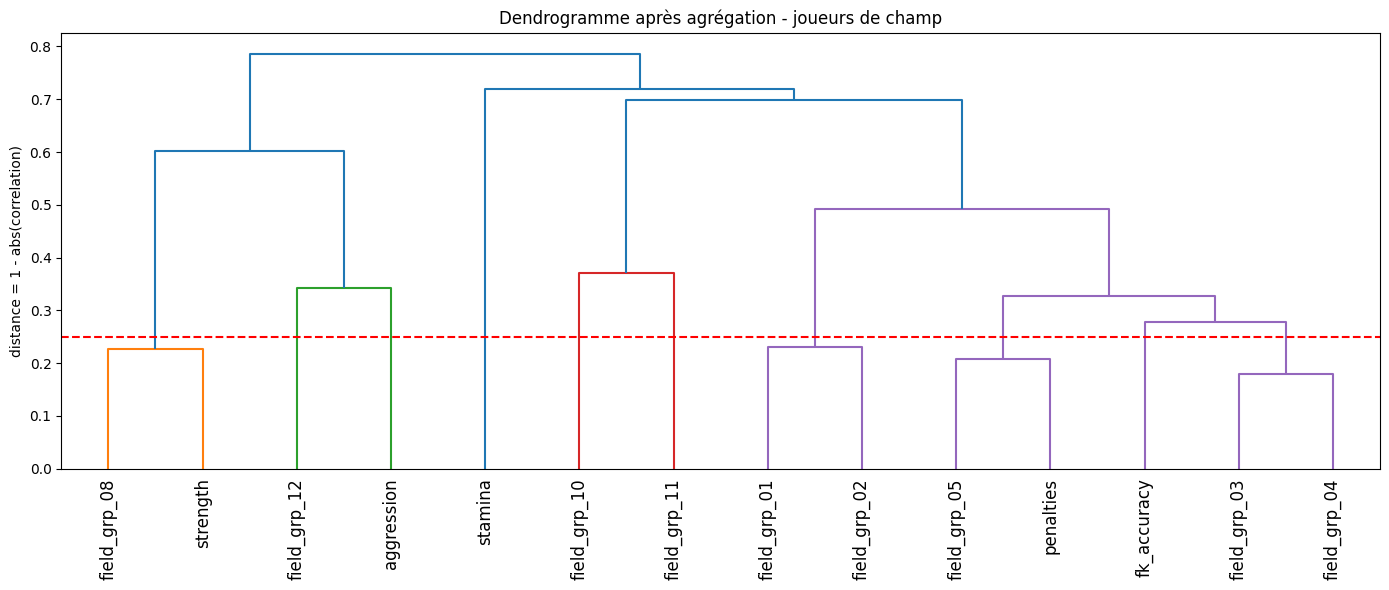

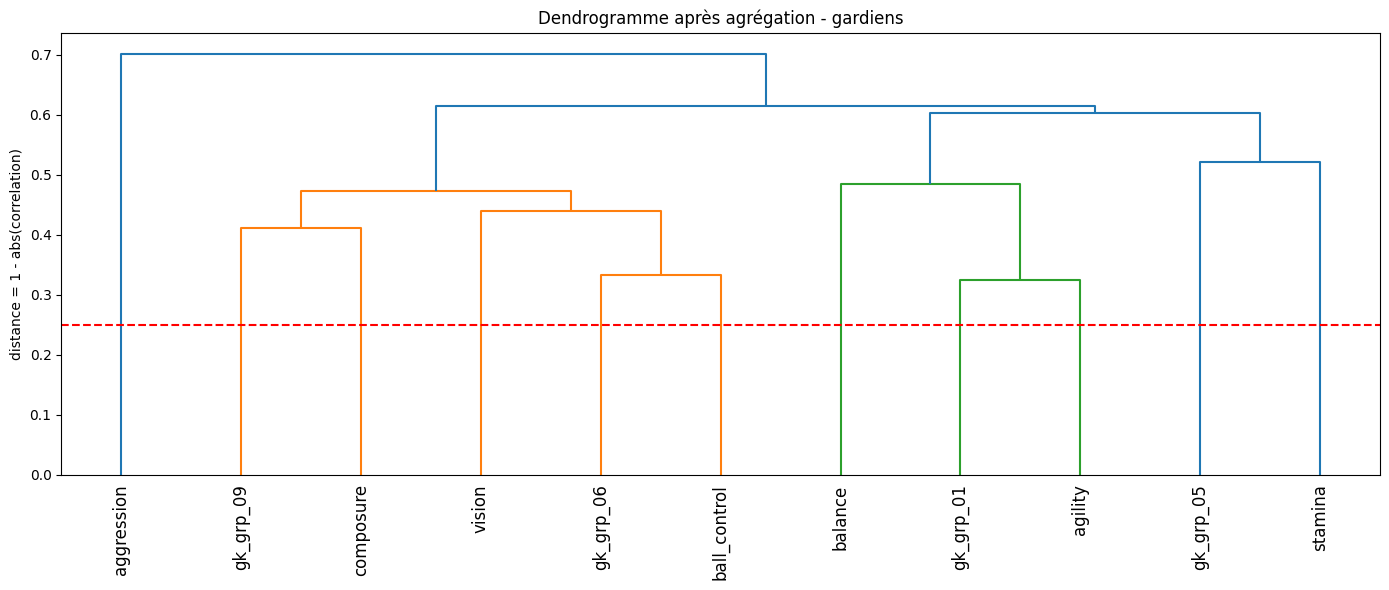

In [347]:
def max_abs_correlation(frame, columns):
    corr_df = get_correlation_matrix(frame, columns).abs()

    if len(corr_df.columns) < 2:
        return np.nan

    upper_mask = np.triu(np.ones(corr_df.shape), k=1).astype(bool)
    return corr_df.where(upper_mask).stack().max()


def profile_correlation_control(frame, profile_columns, rating_columns, player_type):
    # On vérifie si une variable de profil apporte une information nouvelle.
    # Si elle est trop corrélée aux ratings, elle est probablement déjà captée par eux.
    correlation_df = get_correlation_matrix(frame, profile_columns + rating_columns).abs()
    usable_rating_columns = [column for column in rating_columns if column in correlation_df.columns]

    rows = []
    for profile_column in profile_columns:
        manual_exclusion = profile_column in MANUALLY_EXCLUDED_PROFILE_FEATURES

        if profile_column not in correlation_df.columns or not usable_rating_columns:
            max_correlation = np.nan
            most_correlated_feature = None
            keep_for_kmeans = False
        else:
            correlations = correlation_df.loc[profile_column, usable_rating_columns].sort_values(ascending=False)
            max_correlation = correlations.iloc[0]
            most_correlated_feature = correlations.index[0]
            keep_for_kmeans = (
                max_correlation < PROFILE_CORRELATION_THRESHOLD
                and not manual_exclusion
            )

        if manual_exclusion:
            drop_reason = "manual_exclusion"
        elif not keep_for_kmeans and pd.notna(max_correlation):
            drop_reason = "high_correlation"
        elif not keep_for_kmeans:
            drop_reason = "not_usable"
        else:
            drop_reason = None

        rows.append({
            "player_type": player_type,
            "profile_feature": profile_column,
            "most_correlated_rating_feature": most_correlated_feature,
            "max_abs_correlation_to_rating": round(max_correlation, 3) if pd.notna(max_correlation) else np.nan,
            "manual_exclusion": manual_exclusion,
            "keep_for_kmeans": keep_for_kmeans,
            "drop_reason": drop_reason,
        })

    return pd.DataFrame(rows)


def add_style_features(frame, rating_columns, player_type):
    # Niveau moyen du joueur : approximation simple du niveau absolu.
    # Style : ce que le joueur a au-dessus/en-dessous de son propre niveau moyen.
    result_df = frame.copy()
    level_column = f"{player_type}_level_score"
    result_df[level_column] = result_df[rating_columns].mean(axis=1).round(3)

    style_columns = []
    for column in rating_columns:
        style_column = f"style_{column}"
        result_df[style_column] = (result_df[column] - result_df[level_column]).round(3)
        style_columns.append(style_column)

    return result_df, level_column, style_columns


field_aggregated_rating_columns = field_aggregation_mapping_df["output_feature"].unique().tolist()
gk_aggregated_rating_columns = gk_aggregation_mapping_df["output_feature"].unique().tolist()

field_profile_control_df = profile_correlation_control(
    field_aggregated_df,
    outfield_profile_attributes,
    field_aggregated_rating_columns,
    player_type="field",
)

gk_profile_control_df = profile_correlation_control(
    gk_aggregated_df,
    goalkeeper_profile_attributes,
    gk_aggregated_rating_columns,
    player_type="goalkeeper",
)

profile_control_df = pd.concat(
    [field_profile_control_df, gk_profile_control_df],
    ignore_index=True,
)

field_selected_profile_columns = field_profile_control_df.loc[
    field_profile_control_df["keep_for_kmeans"],
    "profile_feature",
].tolist()
gk_selected_profile_columns = gk_profile_control_df.loc[
    gk_profile_control_df["keep_for_kmeans"],
    "profile_feature",
].tolist()

field_aggregated_df, field_level_column, field_style_rating_columns = add_style_features(
    field_aggregated_df,
    field_aggregated_rating_columns,
    player_type="field",
)

gk_aggregated_df, gk_level_column, gk_style_rating_columns = add_style_features(
    gk_aggregated_df,
    gk_aggregated_rating_columns,
    player_type="goalkeeper",
)

# On reconstruit la table combinee apres creation des styles.
players_aggregated_features_df = pd.concat(
    [field_aggregated_df, gk_aggregated_df],
    ignore_index=True,
    sort=False,
)
players_aggregated_features_df["position_role"] = players_aggregated_features_df["best_position"].map(position_to_role)
role_players_aggregated_features_df = players_aggregated_features_df[
    players_aggregated_features_df["position_role"].notna()
].copy()

field_absolute_final_columns = field_aggregated_rating_columns + field_selected_profile_columns
gk_absolute_final_columns = gk_aggregated_rating_columns + gk_selected_profile_columns

field_style_final_columns = field_style_rating_columns + field_selected_profile_columns
gk_style_final_columns = gk_style_rating_columns + gk_selected_profile_columns

if CLUSTERING_FEATURE_MODE == "absolute":
    field_final_columns = field_absolute_final_columns
    gk_final_columns = gk_absolute_final_columns
elif CLUSTERING_FEATURE_MODE == "style":
    field_final_columns = field_style_final_columns
    gk_final_columns = gk_style_final_columns
else:
    raise ValueError("CLUSTERING_FEATURE_MODE doit être 'absolute' ou 'style'.")

correlation_reduction_df = pd.DataFrame([
    {
        "player_type": "field",
        "max_abs_corr_before": max_abs_correlation(field_players_df, outfield_rating_attributes),
        "max_abs_corr_after_aggregation": max_abs_correlation(field_aggregated_df, field_aggregated_rating_columns),
        "feature_mode": CLUSTERING_FEATURE_MODE,
        "kept_profile_features": field_selected_profile_columns,
        "dropped_profile_features": field_profile_control_df.loc[~field_profile_control_df["keep_for_kmeans"], "profile_feature"].tolist(),
    },
    {
        "player_type": "goalkeeper",
        "max_abs_corr_before": max_abs_correlation(goalkeepers_df, goalkeeper_rating_attributes),
        "max_abs_corr_after_aggregation": max_abs_correlation(gk_aggregated_df, gk_aggregated_rating_columns),
        "feature_mode": CLUSTERING_FEATURE_MODE,
        "kept_profile_features": gk_selected_profile_columns,
        "dropped_profile_features": gk_profile_control_df.loc[~gk_profile_control_df["keep_for_kmeans"], "profile_feature"].tolist(),
    },
]).round(3)

style_feature_summary_df = pd.DataFrame([
    {
        "player_type": "field",
        "level_column": field_level_column,
        "rating_feature_count": len(field_aggregated_rating_columns),
        "style_feature_count": len(field_style_rating_columns),
        "selected_profile_features": field_selected_profile_columns,
        "final_feature_count": len(field_final_columns),
    },
    {
        "player_type": "goalkeeper",
        "level_column": gk_level_column,
        "rating_feature_count": len(gk_aggregated_rating_columns),
        "style_feature_count": len(gk_style_rating_columns),
        "selected_profile_features": gk_selected_profile_columns,
        "final_feature_count": len(gk_final_columns),
    },
])

field_final_corr_df = get_correlation_matrix(field_aggregated_df, field_aggregated_rating_columns)
gk_final_corr_df = get_correlation_matrix(gk_aggregated_df, gk_aggregated_rating_columns)

print("Contrôle des variables de profil")
display(profile_control_df)

display(correlation_reduction_df)
display(style_feature_summary_df)

plot_feature_dendrogram(field_final_corr_df, "Dendrogramme après agrégation - joueurs de champ")
plot_feature_dendrogram(gk_final_corr_df, "Dendrogramme après agrégation - gardiens")


## 11. Préparer la suite clustering par rôle

`role_players_aggregated_features_df` devient la base de travail pour le clustering.

On clusterise selon `position_role`, plus précis que les grandes lignes : central defender, fullback/wingback, milieux par rôle, wide players, forwards.

Le mode actif est `CLUSTERING_FEATURE_MODE = "style"` : les ratings utilisés par KMeans sont des écarts au niveau moyen du joueur. Les gardiens sont inclus dans le rôle `goalkeeper`, avec leurs propres features gardien.


In [348]:
# Le rôle goalkeeper utilise les features gardien.
# Tous les autres rôles utilisent uniquement les features joueurs de champ.
feature_columns_by_role = {
    role: (gk_final_columns if role == "goalkeeper" else field_final_columns)
    for role in ROLE_GROUPS
}

role_feature_summary_df = pd.DataFrame([
    {
        "position_role": role,
        "positions_included": ROLE_GROUPS[role],
        "feature_count": len(feature_columns),
        "features": feature_columns,
    }
    for role, feature_columns in feature_columns_by_role.items()
]).sort_values("position_role")

display(role_feature_summary_df)


,position_role,positions_included,feature_count,features
0,attacking_midfielder,[CAM],16,"[style_field_grp_05, style_field_grp_12, style..."
1,central_defender,[CB],16,"[style_field_grp_05, style_field_grp_12, style..."
2,central_midfielder,[CM],16,"[style_field_grp_05, style_field_grp_12, style..."
3,defensive_midfielder,[CDM],16,"[style_field_grp_05, style_field_grp_12, style..."
4,forward,"[CF, ST]",16,"[style_field_grp_05, style_field_grp_12, style..."
5,fullback_wingback,"[LB, LWB, RB, RWB]",16,"[style_field_grp_05, style_field_grp_12, style..."
6,goalkeeper,[GK],13,"[style_gk_grp_09, style_gk_grp_01, style_gk_gr..."
7,wide_player,"[LM, LW, RM, RW]",16,"[style_field_grp_05, style_field_grp_12, style..."


## 12. Résumé des entrées par rôle

Pour chaque rôle, on vérifie le nombre de joueurs, les postes exacts inclus, et les features réellement utilisables.


In [349]:
role_input_rows = []

for role, feature_columns in feature_columns_by_role.items():
    role_df = role_players_aggregated_features_df[
        role_players_aggregated_features_df["position_role"] == role
    ]

    usable_features = [
        column
        for column in feature_columns
        if column in role_df.columns
        and role_df[column].notna().all()
        and role_df[column].nunique(dropna=True) > 1
    ]

    role_input_rows.append({
        "position_role": role,
        "positions_included": sorted(role_df["best_position"].dropna().unique()),
        "player_count": len(role_df),
        "feature_count": len(usable_features),
        "ready_for_kmeans": len(role_df) >= MIN_PLAYERS_BY_ROLE and len(usable_features) >= 2,
        "features": usable_features,
    })

role_kmeans_input_df = (
    pd.DataFrame(role_input_rows)
    .sort_values("position_role")
    .reset_index(drop=True)
)

display(role_kmeans_input_df)


,position_role,positions_included,player_count,feature_count,ready_for_kmeans,features
0,attacking_midfielder,[CAM],762,16,True,"[style_field_grp_05, style_field_grp_12, style..."
1,central_defender,[CB],995,16,True,"[style_field_grp_05, style_field_grp_12, style..."
2,central_midfielder,[CM],404,16,True,"[style_field_grp_05, style_field_grp_12, style..."
3,defensive_midfielder,[CDM],354,16,True,"[style_field_grp_05, style_field_grp_12, style..."
4,forward,"[CF, ST]",712,16,True,"[style_field_grp_05, style_field_grp_12, style..."
5,fullback_wingback,"[LB, LWB, RB, RWB]",602,16,True,"[style_field_grp_05, style_field_grp_12, style..."
6,goalkeeper,[GK],505,13,True,"[style_gk_grp_09, style_gk_grp_01, style_gk_gr..."
7,wide_player,"[LM, LW, RM, RW]",689,16,True,"[style_field_grp_05, style_field_grp_12, style..."


## 13. Evaluation KMeans par rôle

On teste plusieurs nombres de clusters pour chaque rôle.

A lire :

- `inertia` : sert au graphe du coude, plus bas est mieux mais il baisse toujours quand `k` augmente ;
- `silhouette` : mesure si les clusters sont bien séparés, plus haut est mieux.


In [350]:
def prepare_role_matrix(role):
    role_df = role_players_aggregated_features_df[
        role_players_aggregated_features_df["position_role"] == role
    ].copy()

    feature_columns = [
        column
        for column in feature_columns_by_role[role]
        if column in role_df.columns
        and role_df[column].notna().all()
        and role_df[column].nunique(dropna=True) > 1
    ]

    # Standardisation obligatoire pour KMeans : chaque feature compte sur la même échelle.
    scaler = StandardScaler()
    scaled_matrix = scaler.fit_transform(role_df[feature_columns])

    return role_df, feature_columns, scaled_matrix, scaler


def evaluate_kmeans_for_role(role):
    role_df, feature_columns, scaled_matrix, _ = prepare_role_matrix(role)

    if len(role_df) < MIN_PLAYERS_BY_ROLE or len(feature_columns) < 2:
        return pd.DataFrame()

    rows = []
    max_k = min(max(K_RANGE), len(role_df) - 1)

    for k in K_RANGE:
        if k > max_k:
            continue

        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=20,
        )
        labels = model.fit_predict(scaled_matrix)
        real_cluster_count = len(set(labels))

        # La silhouette est calculable seulement si au moins deux clusters réels existent.
        silhouette = np.nan
        if 1 < real_cluster_count < len(role_df):
            silhouette = silhouette_score(scaled_matrix, labels)

        rows.append({
            "position_role": role,
            "positions_included": sorted(role_df["best_position"].dropna().unique()),
            "player_count": len(role_df),
            "feature_count": len(feature_columns),
            "k": k,
            "real_cluster_count": real_cluster_count,
            "inertia": model.inertia_,
            "silhouette": silhouette,
        })

    return pd.DataFrame(rows)


kmeans_scores_by_role = {}
score_frames = []

for role in role_kmeans_input_df.query("ready_for_kmeans")["position_role"]:
    scores_df = evaluate_kmeans_for_role(role)
    kmeans_scores_by_role[role] = scores_df

    if not scores_df.empty:
        score_frames.append(scores_df)

kmeans_scores_df = pd.concat(score_frames, ignore_index=True) if score_frames else pd.DataFrame()

display(kmeans_scores_df.round({"inertia": 1, "silhouette": 3}))


,position_role,positions_included,player_count,feature_count,k,real_cluster_count,inertia,silhouette
0,attacking_midfielder,[CAM],762,16,2,2,9985.2,0.164
1,attacking_midfielder,[CAM],762,16,3,3,9116.0,0.144
2,attacking_midfielder,[CAM],762,16,4,4,8497.9,0.112
3,attacking_midfielder,[CAM],762,16,5,5,8038.3,0.108
4,attacking_midfielder,[CAM],762,16,6,6,7748.6,0.098
5,attacking_midfielder,[CAM],762,16,7,7,7479.8,0.100
6,attacking_midfielder,[CAM],762,16,8,8,7290.6,0.096
7,attacking_midfielder,[CAM],762,16,9,9,7112.8,0.092
8,attacking_midfielder,[CAM],762,16,10,10,6975.0,0.086
9,central_defender,[CB],995,16,2,2,13111.5,0.160


## 14. Graphes coude et silhouette

On ne choisit pas encore le nombre de clusters. Le but ici est seulement de lire les graphes rôle par rôle.


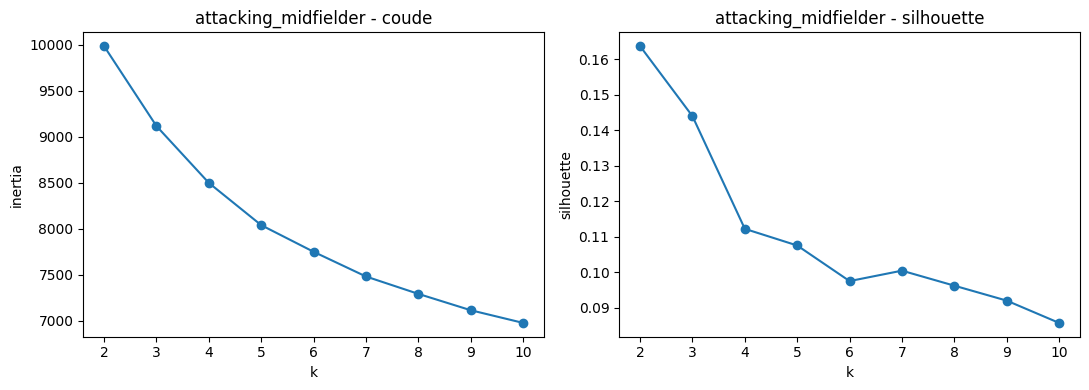

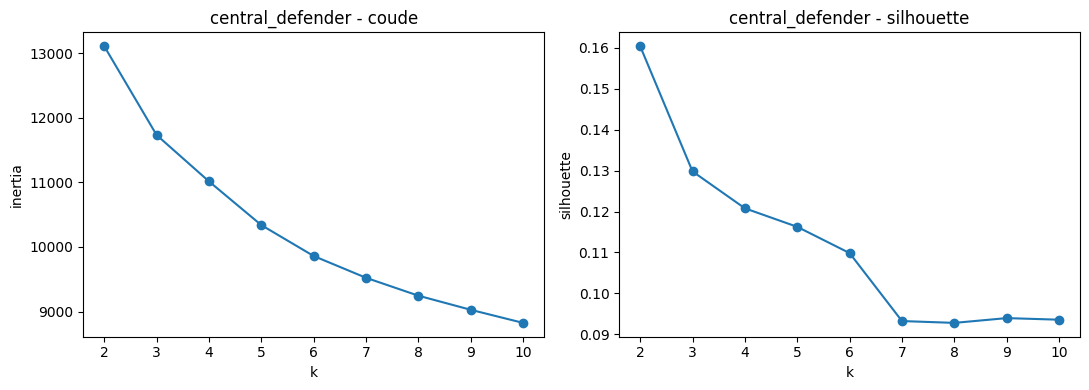

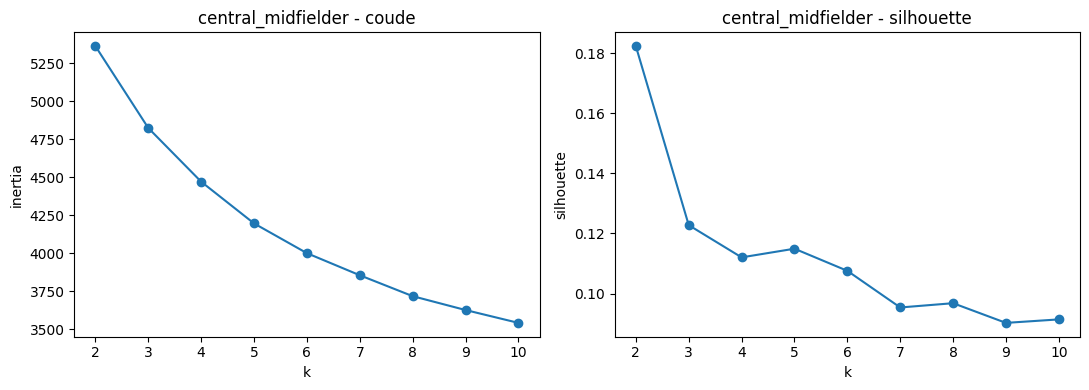

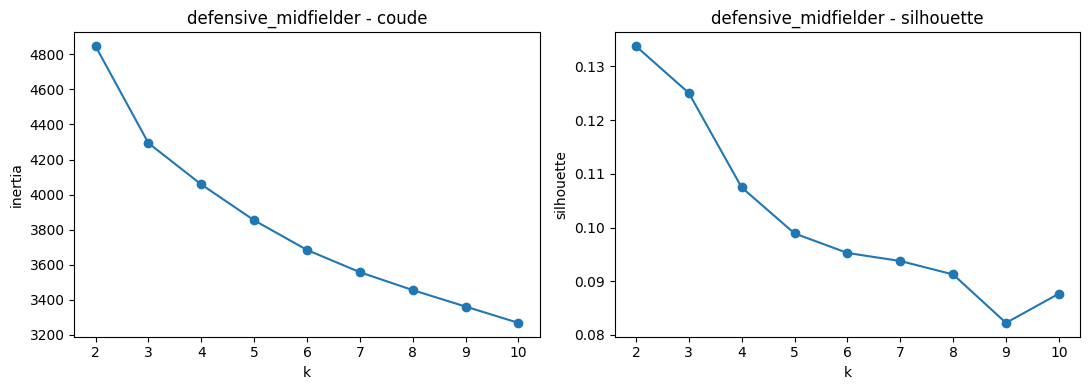

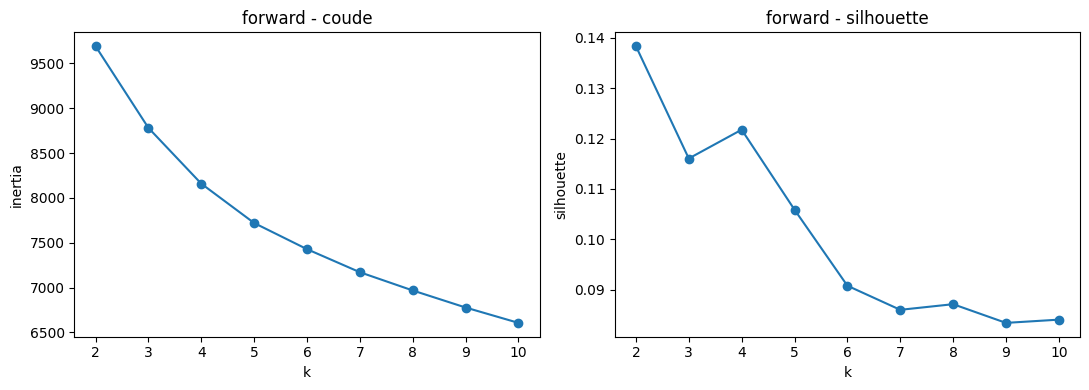

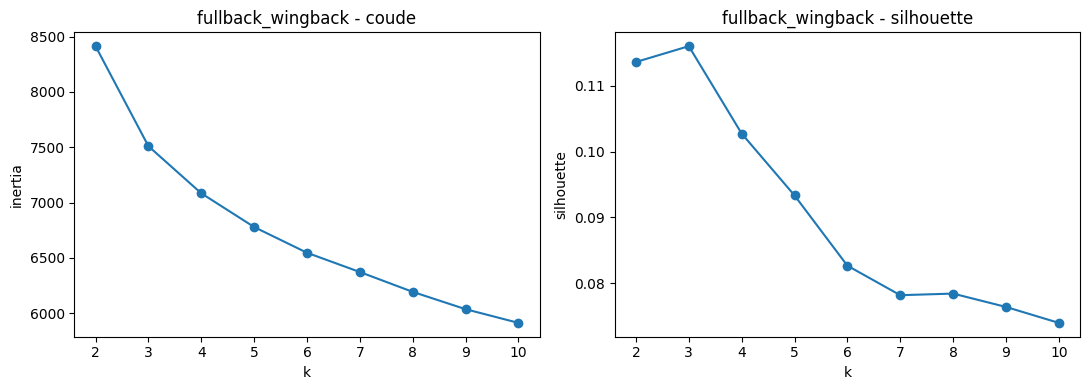

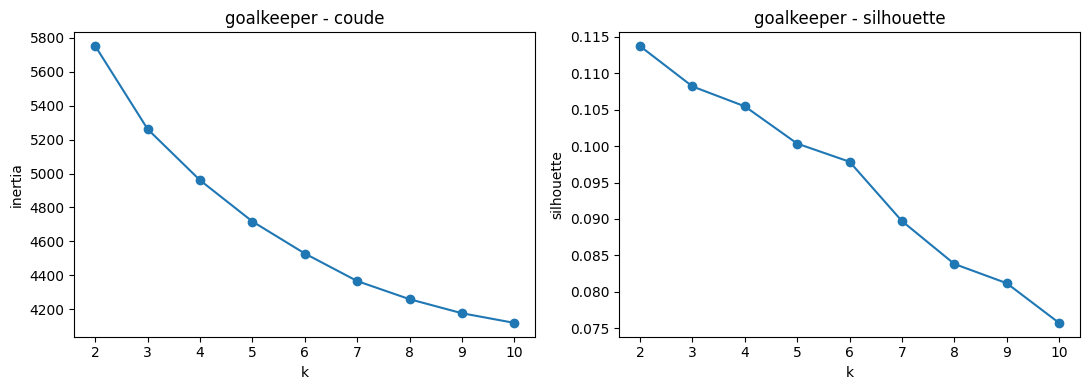

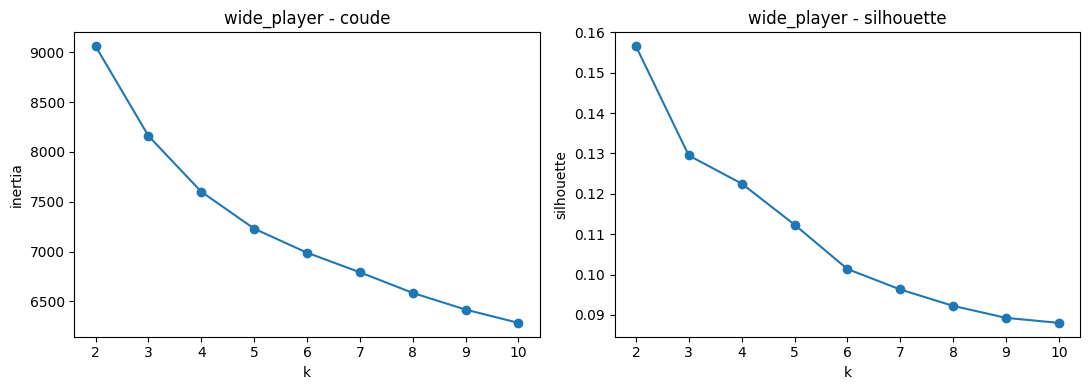

In [351]:
def plot_kmeans_scores_for_role(role, scores_df):
    if scores_df.empty:
        print(f"{role}: pas assez de données pour KMeans")
        return

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(scores_df["k"], scores_df["inertia"], marker="o")
    axes[0].set_title(f"{role} - coude")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("inertia")

    axes[1].plot(scores_df["k"], scores_df["silhouette"], marker="o")
    axes[1].set_title(f"{role} - silhouette")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("silhouette")

    plt.tight_layout()
    plt.show()
    plt.close(fig)


for role, scores_df in kmeans_scores_by_role.items():
    plot_kmeans_scores_for_role(role, scores_df)


## 15. Comparer les profils par k candidat

Avant de figer définitivement le nombre de clusters, on regarde si les clusters racontent vraiment des profils.

Pour chaque rôle, on teste quelques valeurs autour du choix actuel.


In [352]:
K_CANDIDATES_BY_ROLE = {
    "attacking_midfielder": [2, 3, 4],
    "central_defender": [3, 4, 5],
    "central_midfielder": [2, 3, 4],
    "defensive_midfielder": [4, 5, 6],
    "forward": [2, 3],
    "fullback_wingback": [2, 3],
    "goalkeeper": [2, 3],
    "wide_player": [4, 5, 6],
}

candidate_k_df = pd.DataFrame([
    {
        "position_role": role,
        "positions_included": ROLE_GROUPS[role],
        "candidate_k": candidate_k,
    }
    for role, candidate_values in K_CANDIDATES_BY_ROLE.items()
    for candidate_k in candidate_values
]).sort_values(["position_role", "candidate_k"])

display(candidate_k_df)


,position_role,positions_included,candidate_k
0,attacking_midfielder,[CAM],2
1,attacking_midfielder,[CAM],3
2,attacking_midfielder,[CAM],4
3,central_defender,[CB],3
4,central_defender,[CB],4
5,central_defender,[CB],5
6,central_midfielder,[CM],2
7,central_midfielder,[CM],3
8,central_midfielder,[CM],4
9,defensive_midfielder,[CDM],4


## 16. Signatures des clusters candidats

Pour chaque `role/k/cluster`, on calcule les features qui montent ou baissent le plus par rapport à la moyenne du rôle.

C'est cette table qui aide à savoir si un cluster est un vrai profil ou seulement un niveau global.


In [353]:
def format_high_feature_differences(row, top_n=5):
    # Format court pour lire les écarts positifs les plus forts.
    values = pd.to_numeric(row, errors="coerce").dropna().sort_values(ascending=False).head(top_n)
    return ", ".join([f"{feature} ({value:+.2f})" for feature, value in values.items()])


def format_low_feature_differences(row, top_n=5):
    # Format court pour lire les écarts négatifs les plus forts.
    values = pd.to_numeric(row, errors="coerce").dropna().sort_values(ascending=True).head(top_n)
    return ", ".join([f"{feature} ({value:+.2f})" for feature, value in values.items()])


def summarize_zscore_row(zscore_row, top_n=5):
    # Cette fonction répond à la question : profil réel ou simple axe fort/faible ?
    values = pd.to_numeric(zscore_row, errors="coerce").dropna()
    positive_feature_count = int((values >= PROFILE_ZSCORE_THRESHOLD).sum())
    negative_feature_count = int((values <= -PROFILE_ZSCORE_THRESHOLD).sum())
    strong_feature_count = positive_feature_count + negative_feature_count

    profile_signal = values.abs().sort_values(ascending=False).head(top_n).mean()
    level_bias = abs(values.mean())
    positive_direction_share = (values > 0).mean()
    negative_direction_share = (values < 0).mean()
    same_direction_share = max(positive_direction_share, negative_direction_share)

    if strong_feature_count < 3:
        profile_read = "weak_signature"
    elif same_direction_share >= 0.75 and level_bias >= PROFILE_ZSCORE_THRESHOLD:
        profile_read = "level_axis"
    elif positive_feature_count >= 2 and negative_feature_count >= 2:
        profile_read = "profile_signature"
    else:
        profile_read = "mixed_or_level"

    return {
        "profile_read": profile_read,
        "profile_signal": round(profile_signal, 2),
        "level_bias": round(level_bias, 2),
        "same_direction_share": round(same_direction_share, 2),
        "positive_feature_count": positive_feature_count,
        "negative_feature_count": negative_feature_count,
        "strong_feature_count": strong_feature_count,
        "top_positive_features": format_high_feature_differences(zscore_row, top_n=top_n),
        "top_negative_features": format_low_feature_differences(zscore_row, top_n=top_n),
    }


def fit_candidate_kmeans(role, k):
    role_df, feature_columns, scaled_matrix, scaler = prepare_role_matrix(role)

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50,
    )
    labels = model.fit_predict(scaled_matrix)
    distances = model.transform(scaled_matrix)

    return role_df, feature_columns, scaled_matrix, model, labels, distances


def build_candidate_signature(role, k):
    role_df, feature_columns, scaled_matrix, model, labels, distances = fit_candidate_kmeans(role, k)

    feature_df = role_df[feature_columns].copy()
    role_mean = feature_df.mean()
    role_std = feature_df.std(ddof=0).replace(0, np.nan)

    cluster_mean_df = feature_df.groupby(labels).mean()
    cluster_zscore_df = ((cluster_mean_df - role_mean) / role_std).round(2)

    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    closest_distances = distances[np.arange(len(role_df)), labels]
    mean_distance_by_cluster = pd.Series(closest_distances).groupby(labels).mean().round(3)

    role_position_baseline_df = (
        role_df
        .groupby("best_position")
        .size()
        .reset_index(name="role_position_count")
    )
    role_position_baseline_df["role_total"] = len(role_df)
    role_position_baseline_df["role_position_share"] = (
        role_position_baseline_df["role_position_count"]
        / role_position_baseline_df["role_total"]
    ).round(3)

    position_distribution_df = (
        role_df.assign(cluster_id=labels)
        .groupby(["cluster_id", "best_position"])
        .size()
        .reset_index(name="cluster_position_count")
        .merge(role_position_baseline_df, on="best_position", how="left")
    )
    position_distribution_df["cluster_total"] = position_distribution_df.groupby("cluster_id")["cluster_position_count"].transform("sum")
    position_distribution_df["cluster_position_share"] = (
        position_distribution_df["cluster_position_count"] / position_distribution_df["cluster_total"]
    ).round(3)
    position_distribution_df["overrepresentation_ratio"] = (
        position_distribution_df["cluster_position_share"]
        / position_distribution_df["role_position_share"]
    ).round(2)

    rows = []
    for cluster_id, zscore_row in cluster_zscore_df.iterrows():
        dominant_positions = position_distribution_df[
            position_distribution_df["cluster_id"] == cluster_id
        ].sort_values("cluster_position_count", ascending=False)

        profile_summary = summarize_zscore_row(zscore_row)
        cluster_share = round(cluster_sizes.loc[cluster_id] / len(role_df), 3)

        rows.append({
            "position_role": role,
            "k": k,
            "cluster_id": cluster_id,
            "player_count": int(cluster_sizes.loc[cluster_id]),
            "cluster_share": cluster_share,
            "small_cluster_flag": cluster_share < SMALL_CLUSTER_SHARE_THRESHOLD,
            "mean_distance_to_centroid": mean_distance_by_cluster.loc[cluster_id],
            **profile_summary,
            # Poste exact = contrôle secondaire, pas objectif principal.
            "dominant_position": dominant_positions.iloc[0]["best_position"],
            "dominant_cluster_position_share": dominant_positions.iloc[0]["cluster_position_share"],
            "dominant_role_position_share": dominant_positions.iloc[0]["role_position_share"],
            "dominant_overrepresentation_ratio": dominant_positions.iloc[0]["overrepresentation_ratio"],
        })

    return pd.DataFrame(rows), position_distribution_df, cluster_zscore_df


candidate_signature_frames = []
candidate_position_frames = []
candidate_zscores = {}

for role, candidate_values in K_CANDIDATES_BY_ROLE.items():
    for candidate_k in candidate_values:
        signature_df, position_distribution_df, zscore_df = build_candidate_signature(role, candidate_k)
        candidate_signature_frames.append(signature_df)

        position_distribution_df.insert(0, "position_role", role)
        position_distribution_df.insert(1, "k", candidate_k)
        candidate_position_frames.append(position_distribution_df)

        candidate_zscores[(role, candidate_k)] = zscore_df

candidate_cluster_signatures_df = pd.concat(candidate_signature_frames, ignore_index=True)
candidate_position_distribution_df = pd.concat(candidate_position_frames, ignore_index=True)

summary_rows = []
for (role, candidate_k), group_df in candidate_cluster_signatures_df.groupby(["position_role", "k"]):
    summary_rows.append({
        "position_role": role,
        "k": candidate_k,
        "cluster_count": group_df["cluster_id"].nunique(),
        "min_cluster_share": group_df["cluster_share"].min(),
        "mean_profile_signal": round(group_df["profile_signal"].mean(), 2),
        "profile_signature_clusters": int((group_df["profile_read"] == "profile_signature").sum()),
        "level_axis_clusters": int((group_df["profile_read"] == "level_axis").sum()),
        "weak_signature_clusters": int((group_df["profile_read"] == "weak_signature").sum()),
        "small_clusters": int(group_df["small_cluster_flag"].sum()),
    })

candidate_k_profile_summary_df = pd.DataFrame(summary_rows).sort_values(["position_role", "k"])

print("Résumé par rôle/k : priorité aux signatures de profil")
display(candidate_k_profile_summary_df)

print("Signatures détaillées des clusters candidats")
display(candidate_cluster_signatures_df)


Résumé par rôle/k : priorité aux signatures de profil


,position_role,k,cluster_count,min_cluster_share,mean_profile_signal,profile_signature_clusters,level_axis_clusters,weak_signature_clusters,small_clusters
0,attacking_midfielder,2,2,0.458,0.58,2,0,0,0
1,attacking_midfielder,3,3,0.207,0.75,3,0,0,0
2,attacking_midfielder,4,4,0.159,0.82,4,0,0,0
3,central_defender,3,3,0.269,0.75,2,0,0,0
4,central_defender,4,4,0.096,0.88,4,0,0,0
5,central_defender,5,5,0.096,0.92,5,0,0,0
6,central_midfielder,2,2,0.322,0.60,1,0,0,0
7,central_midfielder,3,3,0.225,0.74,2,0,0,0
8,central_midfielder,4,4,0.119,0.81,4,0,0,0
9,defensive_midfielder,4,4,0.178,0.80,3,0,0,0


Signatures détaillées des clusters candidats


,position_role,k,cluster_id,player_count,cluster_share,small_cluster_flag,mean_distance_to_centroid,profile_read,profile_signal,level_bias,same_direction_share,positive_feature_count,negative_feature_count,strong_feature_count,top_positive_features,top_negative_features,dominant_position,dominant_cluster_position_share,dominant_role_position_share,dominant_overrepresentation_ratio
0,attacking_midfielder,2,0,413,0.542,False,3.401,profile_signature,0.53,0.12,0.69,2,4,6,"style_field_grp_12 (+0.51), style_aggression (...","style_field_grp_03 (-0.57), style_field_grp_04...",CAM,1.000,1.000,1.00
1,attacking_midfielder,2,1,349,0.458,False,3.649,profile_signature,0.63,0.14,0.69,5,4,9,"style_field_grp_03 (+0.67), style_field_grp_04...","style_field_grp_12 (-0.61), style_aggression (...",CAM,1.000,1.000,1.00
2,attacking_midfielder,3,0,332,0.436,False,3.240,profile_signature,0.65,0.14,0.69,3,6,9,"style_field_grp_12 (+0.64), style_aggression (...","style_field_grp_03 (-0.70), style_field_grp_05...",CAM,1.000,1.000,1.00
3,attacking_midfielder,3,1,272,0.357,False,3.390,profile_signature,0.68,0.08,0.56,3,4,7,"style_field_grp_10 (+0.79), style_field_grp_11...","style_field_grp_12 (-0.61), style_aggression (...",CAM,1.000,1.000,1.00
4,attacking_midfielder,3,2,158,0.207,False,3.587,profile_signature,0.92,0.16,0.56,7,3,10,"style_fk_accuracy (+0.92), style_field_grp_04 ...","style_field_grp_10 (-1.02), style_stamina (-0....",CAM,1.000,1.000,1.00
5,attacking_midfielder,4,0,121,0.159,False,3.559,profile_signature,1.01,0.23,0.56,8,6,14,"style_field_grp_04 (+1.14), style_field_grp_01...","style_stamina (-0.90), style_field_grp_10 (-0....",CAM,1.000,1.000,1.00
6,attacking_midfielder,4,1,248,0.325,False,3.327,profile_signature,0.67,0.06,0.56,3,3,6,"style_field_grp_10 (+0.86), style_field_grp_11...","style_field_grp_12 (-0.63), style_aggression (...",CAM,1.000,1.000,1.00
7,attacking_midfielder,4,2,192,0.252,False,3.093,profile_signature,0.94,0.17,0.62,2,6,8,"style_field_grp_12 (+0.99), style_aggression (...","style_field_grp_05 (-1.02), style_field_grp_04...",CAM,1.000,1.000,1.00
8,attacking_midfielder,4,3,201,0.264,False,3.112,profile_signature,0.65,0.05,0.62,3,5,8,"style_strength (+0.54), style_field_grp_08 (+0...","style_field_grp_11 (-0.84), style_field_grp_03...",CAM,1.000,1.000,1.00
9,central_defender,3,0,303,0.305,False,3.418,profile_signature,0.81,0.11,0.50,6,3,9,"style_field_grp_02 (+0.94), style_field_grp_12...","style_field_grp_11 (-0.77), style_fk_accuracy ...",CB,1.000,1.000,1.00


## 17. Heatmaps des profils candidats

Chaque heatmap montre les écarts standardisés des clusters par rapport à la moyenne du rôle.

Lecture :

- rouge : feature plus forte que la moyenne du rôle ;
- bleu : feature plus faible que la moyenne du rôle.


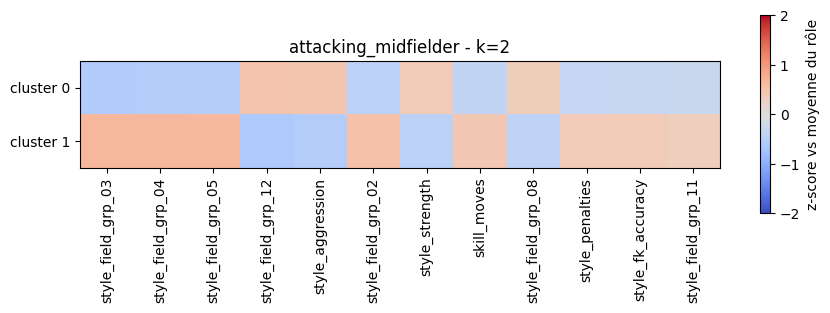

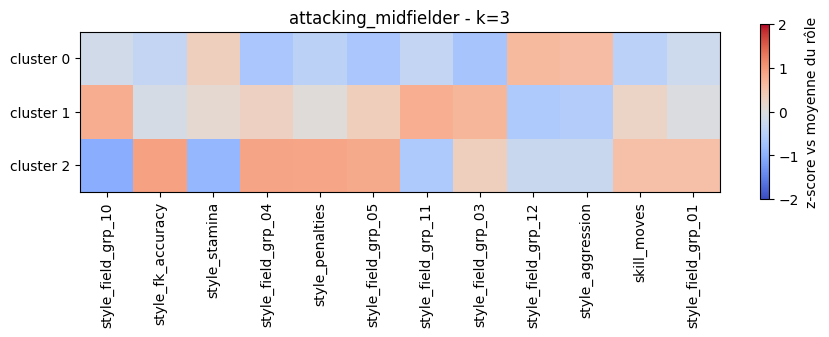

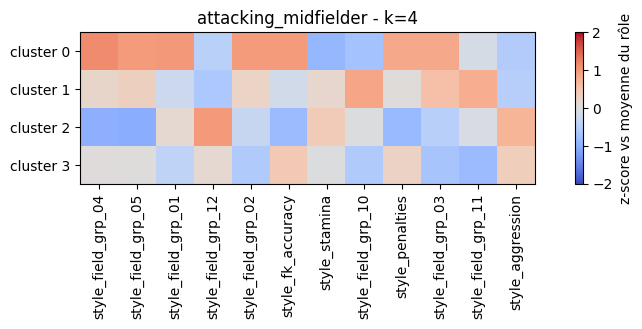

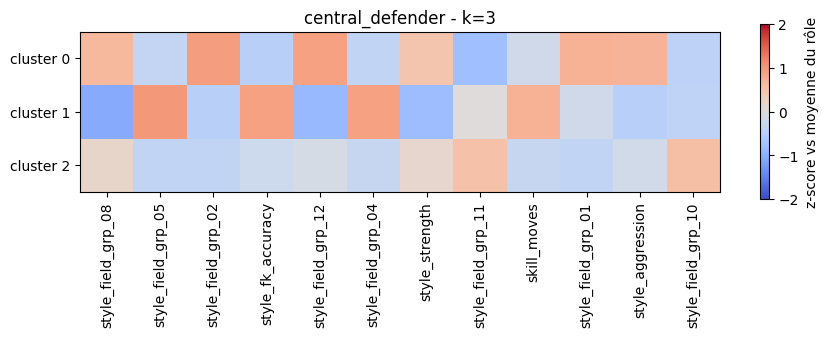

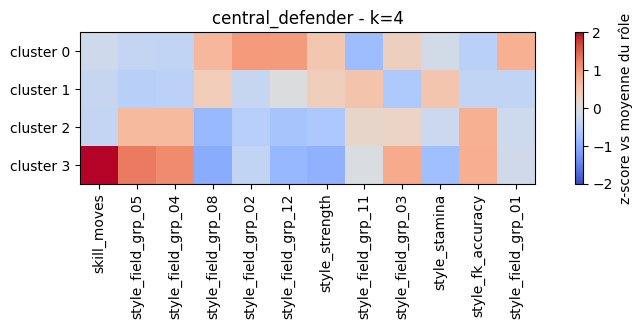

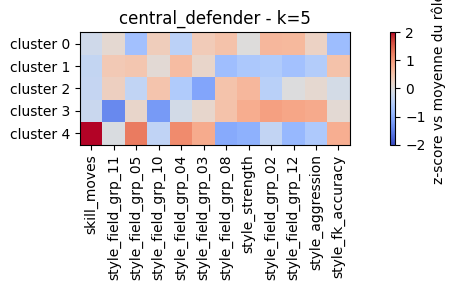

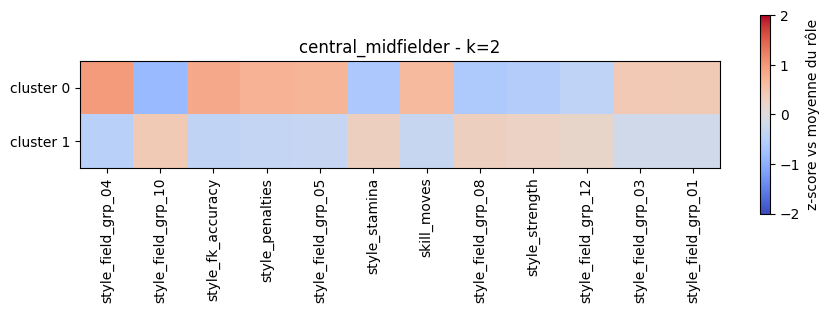

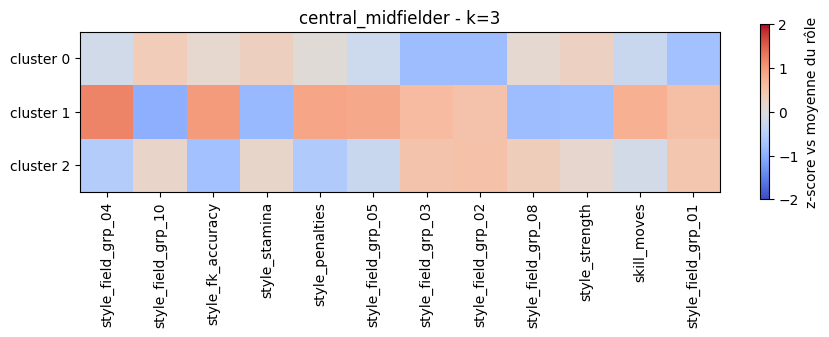

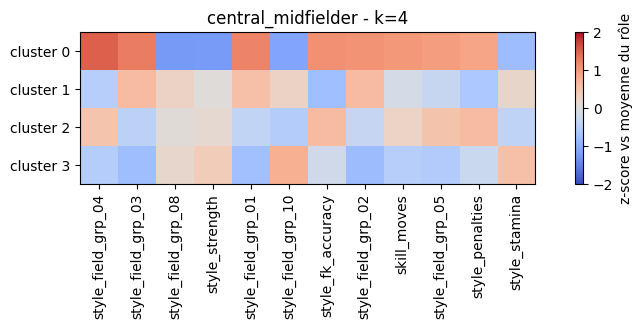

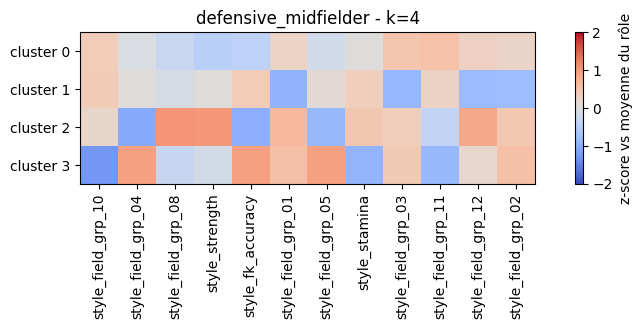

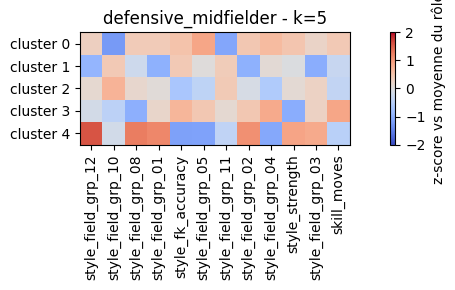

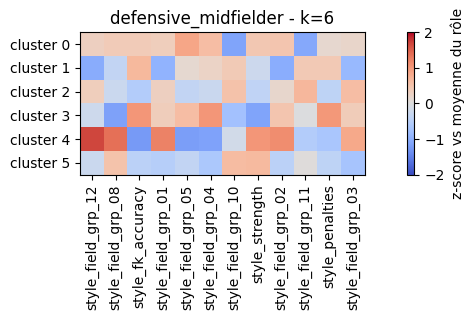

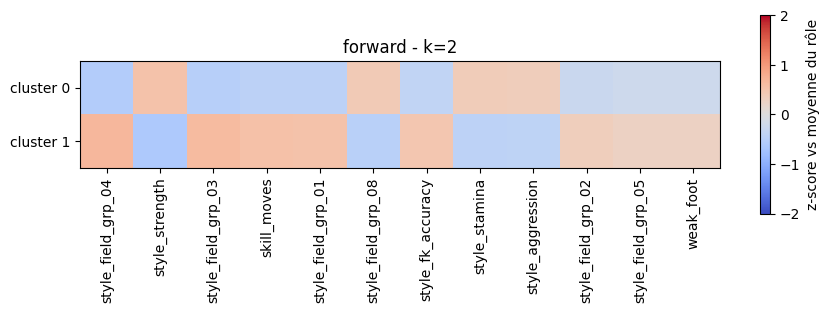

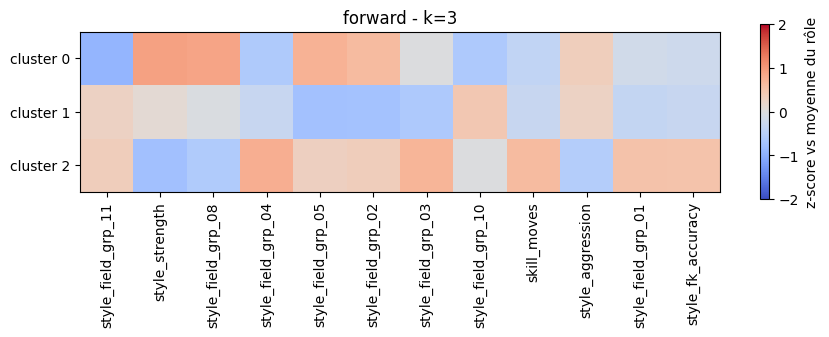

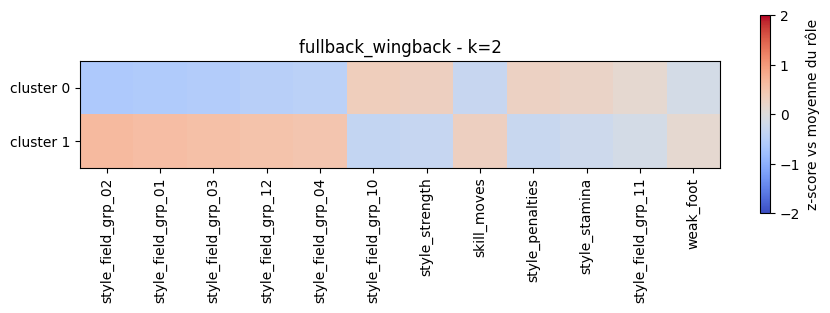

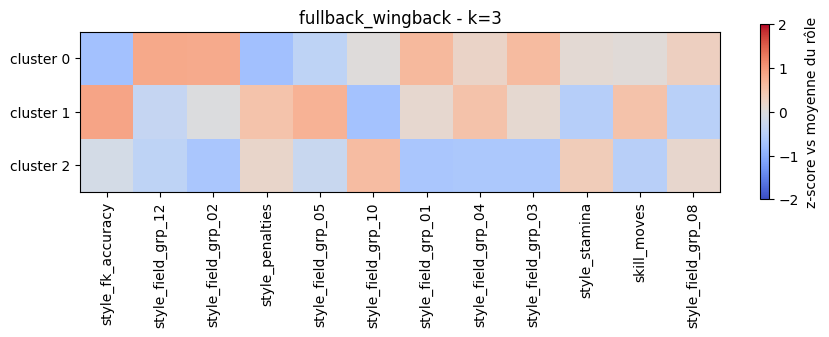

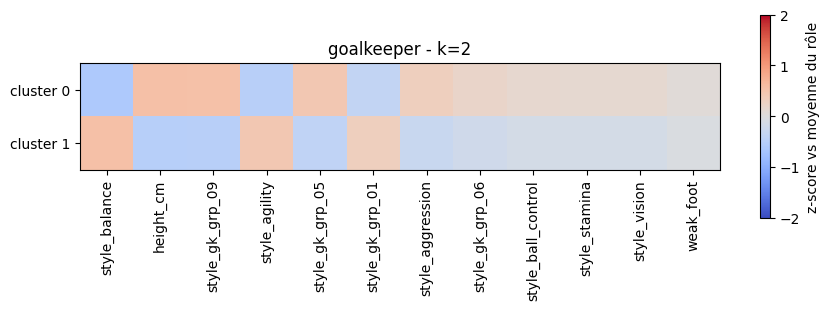

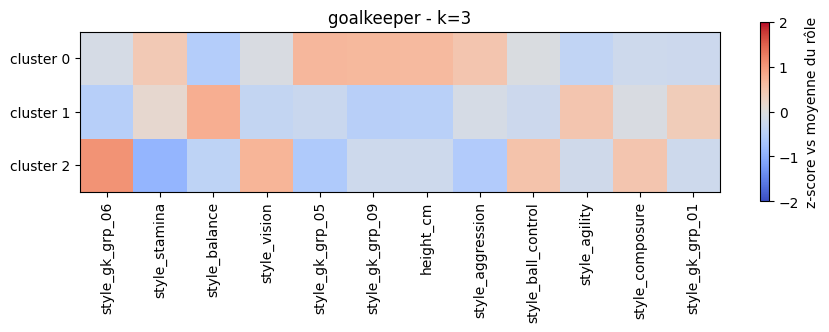

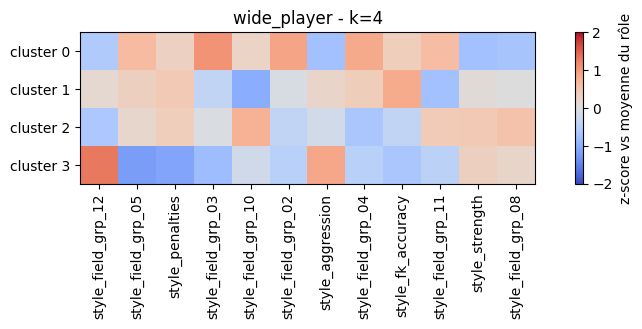

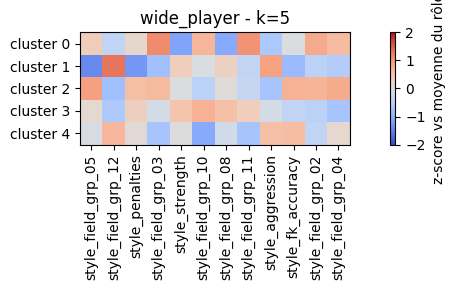

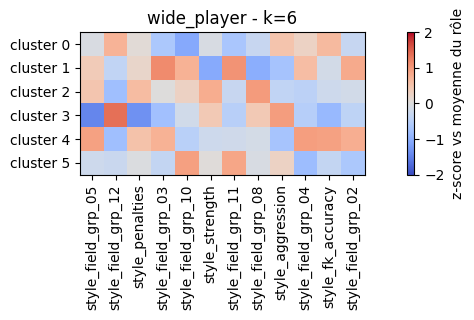

In [354]:
def plot_candidate_profile_heatmap(role, k, top_n_features=12):
    zscore_df = candidate_zscores[(role, k)]

    # On garde les features qui différencient le plus les clusters.
    selected_features = (
        zscore_df.abs()
        .max(axis=0)
        .sort_values(ascending=False)
        .head(top_n_features)
        .index
        .tolist()
    )
    plot_df = zscore_df[selected_features]

    fig = plt.figure(figsize=(max(9, len(selected_features) * 0.7), max(3, len(plot_df) * 0.55)))
    plt.imshow(plot_df, cmap="coolwarm", vmin=-2, vmax=2)
    plt.colorbar(label="z-score vs moyenne du rôle")
    plt.xticks(range(len(selected_features)), selected_features, rotation=90)
    plt.yticks(range(len(plot_df)), [f"cluster {cluster_id}" for cluster_id in plot_df.index])
    plt.title(f"{role} - k={k}")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


for role, candidate_values in K_CANDIDATES_BY_ROLE.items():
    for candidate_k in candidate_values:
        plot_candidate_profile_heatmap(role, candidate_k)


## 18. Distribution des postes exacts par cluster candidat

Ce contrôle aide à voir si un cluster représente un vrai profil ou seulement un sous-poste déjà connu.

Colonnes importantes :

- `cluster_position_share` : part du poste exact dans le cluster ;
- `role_position_share` : part du même poste exact dans tout le rôle avant clustering ;
- `overrepresentation_ratio` : ratio entre les deux.

Un ratio proche de `1` signifie que le poste n'est pas spécialement surreprésenté dans le cluster.


In [355]:
display(candidate_position_distribution_df)


,position_role,k,cluster_id,best_position,cluster_position_count,role_position_count,role_total,role_position_share,cluster_total,cluster_position_share,overrepresentation_ratio
0,attacking_midfielder,2,0,CAM,413,762,762,1.000,413,1.000,1.00
1,attacking_midfielder,2,1,CAM,349,762,762,1.000,349,1.000,1.00
2,attacking_midfielder,3,0,CAM,332,762,762,1.000,332,1.000,1.00
3,attacking_midfielder,3,1,CAM,272,762,762,1.000,272,1.000,1.00
4,attacking_midfielder,3,2,CAM,158,762,762,1.000,158,1.000,1.00
...,...,...,...,...,...,...,...,...,...,...,...
133,wide_player,6,4,RW,20,78,689,0.113,114,0.175,1.55
134,wide_player,6,5,LM,25,225,689,0.327,104,0.240,0.73
135,wide_player,6,5,LW,4,55,689,0.080,104,0.038,0.48
136,wide_player,6,5,RM,65,331,689,0.480,104,0.625,1.30


## 19. Choix final du nombre de clusters

Choix retenu après lecture des graphes coude/silhouette et des signatures de profils.


In [356]:
CLUSTERS_BY_ROLE = {
    # Choix retenus après lecture des graphes et des signatures en mode style-only.
    "attacking_midfielder": 3,
    "central_defender": 4,
    "central_midfielder": 4,
    "defensive_midfielder": 5,
    "forward": 3,
    "fullback_wingback": 3,
    "goalkeeper": 2,
    "wide_player": 5,
}

chosen_clusters_df = pd.DataFrame([
    {
        "position_role": role,
        "positions_included": ROLE_GROUPS[role],
        "chosen_k": chosen_k,
    }
    for role, chosen_k in CLUSTERS_BY_ROLE.items()
]).sort_values("position_role")

display(chosen_clusters_df)


,position_role,positions_included,chosen_k
0,attacking_midfielder,[CAM],3
1,central_defender,[CB],4
2,central_midfielder,[CM],4
3,defensive_midfielder,[CDM],5
4,forward,"[CF, ST]",3
5,fullback_wingback,"[LB, LWB, RB, RWB]",3
6,goalkeeper,[GK],2
7,wide_player,"[LM, LW, RM, RW]",5


## 20. Fit KMeans final par rôle

On entraîne un KMeans séparé pour chaque rôle, avec le nombre de clusters choisi.


In [357]:
role_models = {}
role_scalers = {}
role_feature_columns = {}
role_cluster_frames = []
role_profile_frames = []

for role, chosen_k in CLUSTERS_BY_ROLE.items():
    role_df, feature_columns, scaled_matrix, scaler = prepare_role_matrix(role)

    if len(role_df) < chosen_k:
        raise ValueError(f"Pas assez de joueurs pour {role}: {len(role_df)} joueurs, k={chosen_k}")

    model = KMeans(
        n_clusters=chosen_k,
        random_state=RANDOM_STATE,
        n_init=50,
    )
    labels = model.fit_predict(scaled_matrix)
    distances = model.transform(scaled_matrix)

    # Table joueur -> cluster.
    clustered_df = role_df[["player_id", "best_position", "position_group", "position_role"]].copy()
    clustered_df["cluster_id"] = labels
    clustered_df["cluster_key"] = clustered_df["position_role"] + "_" + clustered_df["cluster_id"].astype(str)
    clustered_df["distance_to_centroid"] = distances[np.arange(len(clustered_df)), labels].round(3)
    clustered_df["chosen_k"] = chosen_k
    role_cluster_frames.append(clustered_df)

    # Profil moyen des clusters, sur les features utilisées par ce rôle.
    profile_df = role_df[feature_columns].copy()
    profile_df["cluster_id"] = labels
    profile_df = profile_df.groupby("cluster_id")[feature_columns].mean().round(1).reset_index()
    profile_df.insert(0, "position_role", role)
    profile_df.insert(1, "chosen_k", chosen_k)
    role_profile_frames.append(profile_df)

    role_models[role] = model
    role_scalers[role] = scaler
    role_feature_columns[role] = feature_columns

player_role_clusters_df = pd.concat(role_cluster_frames, ignore_index=True)
cluster_profiles_df = pd.concat(role_profile_frames, ignore_index=True)

print("Joueurs clusterisés:", len(player_role_clusters_df))
display(player_role_clusters_df.head())
display(cluster_profiles_df.head())


Joueurs clusterisés: 5023


,player_id,best_position,position_group,position_role,cluster_id,cluster_key,distance_to_centroid,chosen_k
0,889193,CAM,Milieu,attacking_midfielder,1,attacking_midfielder_1,4.877,3
1,646658,CAM,Milieu,attacking_midfielder,0,attacking_midfielder_0,2.485,3
2,724520,CAM,Milieu,attacking_midfielder,1,attacking_midfielder_1,2.830,3
3,340394,CAM,Milieu,attacking_midfielder,0,attacking_midfielder_0,3.187,3
4,592400,CAM,Milieu,attacking_midfielder,0,attacking_midfielder_0,2.483,3


,position_role,chosen_k,cluster_id,style_field_grp_05,style_field_grp_12,style_field_grp_03,style_field_grp_01,style_field_grp_10,style_field_grp_02,style_field_grp_04,style_field_grp_08,style_field_grp_11,style_penalties,style_fk_accuracy,style_strength,style_aggression,style_stamina,skill_moves,weak_foot,style_gk_grp_09,style_gk_grp_01,style_gk_grp_06,style_gk_grp_05,style_agility,style_balance,style_ball_control,style_vision,style_composure,height_cm
0,attacking_midfielder,3,0,-0.5,-10.1,6.2,4.8,6.6,2.5,-1.8,-4.6,9.3,-6.9,-6.1,-1.9,-1.9,4.6,3.1,3.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,attacking_midfielder,3,1,3.6,-26.0,11.5,5.5,15.4,6.0,4.2,-10.4,18.4,-3.2,-4.1,-11.1,-12.9,3.1,3.5,3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,attacking_midfielder,3,2,5.6,-21.8,10.1,7.9,-1.2,6.6,8.0,-7.8,7.2,3.3,4.8,-6.8,-10.2,-5.7,3.7,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,central_defender,4,0,-20.4,15.6,-1.1,9.0,-2.6,11.9,-17.4,17.3,-10.2,-18.5,-27.6,21.4,17.3,5.2,2.0,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,central_defender,4,1,-21.4,11.1,-6.1,3.7,9.2,5.4,-18.3,15.9,1.2,-17.7,-26.5,20.5,12.5,10.6,2.0,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 21. Signatures des profils finaux

C'est la lecture principale des clusters finaux.

On ne cherche pas à retrouver les postes exacts. On regarde si chaque cluster a une signature propre : points forts, points faibles, intensité du profil et risque d'être seulement un axe `fort/faible`.


In [358]:
final_signature_rows = []
final_zscores_by_role = {}

for role, chosen_k in CLUSTERS_BY_ROLE.items():
    role_df, feature_columns, scaled_matrix, scaler = prepare_role_matrix(role)
    role_feature_df = role_df[feature_columns].apply(pd.to_numeric, errors="coerce")
    role_mean = role_feature_df.mean()
    role_std = role_feature_df.std(ddof=0).replace(0, np.nan)

    role_profiles_df = cluster_profiles_df[cluster_profiles_df["position_role"] == role]

    zscore_rows = []
    for _, profile_row in role_profiles_df.iterrows():
        cluster_id = int(profile_row["cluster_id"])
        profile_values = pd.to_numeric(profile_row[feature_columns], errors="coerce")
        zscore_row = ((profile_values - role_mean) / role_std).round(2)
        zscore_row.name = cluster_id
        zscore_rows.append(zscore_row)

        cluster_members_df = player_role_clusters_df[
            (player_role_clusters_df["position_role"] == role)
            & (player_role_clusters_df["cluster_id"] == cluster_id)
        ]

        profile_summary = summarize_zscore_row(zscore_row)
        final_signature_rows.append({
            "position_role": role,
            "cluster_id": cluster_id,
            "cluster_key": f"{role}_{cluster_id}",
            "player_count": len(cluster_members_df),
            "cluster_share": round(len(cluster_members_df) / len(role_df), 3),
            **profile_summary,
        })

    final_zscores_by_role[role] = pd.DataFrame(zscore_rows)

final_cluster_signatures_df = (
    pd.DataFrame(final_signature_rows)
    .sort_values(["position_role", "cluster_id"])
    .reset_index(drop=True)
)

display(final_cluster_signatures_df)


,position_role,cluster_id,cluster_key,player_count,cluster_share,profile_read,profile_signal,level_bias,same_direction_share,positive_feature_count,negative_feature_count,strong_feature_count,top_positive_features,top_negative_features
0,attacking_midfielder,0,attacking_midfielder_0,332,0.436,profile_signature,0.64,0.13,0.62,3,6,9,"style_field_grp_12 (+0.64), style_aggression (...","style_field_grp_03 (-0.69), style_field_grp_04..."
1,attacking_midfielder,1,attacking_midfielder_1,272,0.357,profile_signature,0.68,0.08,0.56,3,4,7,"style_field_grp_10 (+0.79), style_field_grp_11...","style_field_grp_12 (-0.61), style_aggression (..."
2,attacking_midfielder,2,attacking_midfielder_2,158,0.207,profile_signature,0.92,0.15,0.56,7,3,10,"style_fk_accuracy (+0.92), style_field_grp_04 ...","style_field_grp_10 (-1.01), style_stamina (-0...."
3,central_defender,0,central_defender_0,281,0.282,profile_signature,0.85,0.10,0.50,6,3,9,"style_field_grp_02 (+1.00), style_field_grp_12...","style_field_grp_11 (-0.82), style_field_grp_10..."
4,central_defender,1,central_defender_1,368,0.370,profile_signature,0.54,0.06,0.69,3,3,6,"style_field_grp_10 (+0.61), style_field_grp_11...","style_field_grp_03 (-0.62), style_field_grp_05..."
5,central_defender,2,central_defender_2,250,0.251,profile_signature,0.72,0.09,0.56,3,5,8,"style_fk_accuracy (+0.75), style_field_grp_04 ...","style_field_grp_08 (-0.86), style_field_grp_12..."
6,central_defender,3,central_defender_3,96,0.096,profile_signature,1.44,0.15,0.56,7,6,13,"skill_moves (+2.78), style_field_grp_05 (+1.27...","style_field_grp_08 (-1.03), style_strength (-0..."
7,central_midfielder,0,central_midfielder_0,48,0.119,profile_signature,1.28,0.25,0.62,9,6,15,"style_field_grp_04 (+1.49), style_field_grp_03...","style_field_grp_08 (-1.24), style_strength (-1..."
8,central_midfielder,1,central_midfielder_1,130,0.322,profile_signature,0.67,0.06,0.62,4,3,7,"style_field_grp_12 (+0.75), style_field_grp_03...","style_fk_accuracy (-0.77), style_penalties (-0..."
9,central_midfielder,2,central_midfielder_2,116,0.287,profile_signature,0.55,0.00,0.50,4,4,8,"style_fk_accuracy (+0.62), style_penalties (+0...","style_field_grp_10 (-0.54), style_field_grp_11..."


## 22. Nommer les styles de clusters

On transforme les signatures techniques en labels lisibles.

Le label reste volontairement simple : il combine les deux forces relatives les plus marquées du cluster. Les points faibles restent visibles pour éviter de surinterpréter le nom.


In [359]:
FEATURE_STYLE_LABELS = {
    "style_field_grp_05": "finition/frappe",
    "style_field_grp_12": "défense",
    "style_field_grp_03": "technique/création",
    "style_field_grp_01": "passe",
    "style_field_grp_10": "vitesse",
    "style_field_grp_02": "réactivité/calme",
    "style_field_grp_04": "centre/effet",
    "style_field_grp_08": "aérien",
    "style_field_grp_11": "agilité/équilibre",
    "style_penalties": "penalty",
    "style_fk_accuracy": "coup franc",
    "style_strength": "puissance",
    "style_aggression": "agressivité",
    "style_stamina": "endurance",
    "skill_moves": "gestuelle",
    "weak_foot": "pied faible",
    "height_cm": "taille",
    "style_gk_grp_09": "arrêts",
    "style_gk_grp_01": "vitesse",
    "style_gk_grp_06": "relance",
    "style_gk_grp_05": "impact physique",
    "style_agility": "agilité",
    "style_balance": "équilibre",
    "style_ball_control": "contrôle",
    "style_vision": "vision",
    "style_composure": "calme",
}

ROLE_LABEL_PREFIX = {
    "attacking_midfielder": "milieu offensif",
    "central_defender": "défenseur central",
    "central_midfielder": "milieu central",
    "defensive_midfielder": "milieu défensif",
    "forward": "attaquant",
    "fullback_wingback": "latéral/piston",
    "goalkeeper": "gardien",
    "wide_player": "joueur de couloir",
}

def readable_feature_name(feature):
    # Fallback simple si une nouvelle feature apparaît plus tard.
    return FEATURE_STYLE_LABELS.get(feature, feature.replace("style_", "").replace("_", " "))


def get_direction_features(zscore_row, direction, top_n=4):
    values = pd.to_numeric(zscore_row, errors="coerce").dropna()

    if direction == "positive":
        values = values[values >= PROFILE_ZSCORE_THRESHOLD].sort_values(ascending=False)
    else:
        values = values[values <= -PROFILE_ZSCORE_THRESHOLD].sort_values(ascending=True)

    return values.head(top_n)


def unique_readable_features(features):
    labels = []
    for feature in features:
        label = readable_feature_name(feature)
        if label not in labels:
            labels.append(label)

    return labels


def build_style_label(role, positive_features):
    role_prefix = ROLE_LABEL_PREFIX.get(role, role)
    positive_labels = unique_readable_features(positive_features)

    if not positive_labels:
        return f"{role_prefix} - profil peu marqué"

    return f"{role_prefix} - {' / '.join(positive_labels[:2])}"


style_rows = []

for role, zscore_df in final_zscores_by_role.items():
    for cluster_id, zscore_row in zscore_df.iterrows():
        positive_values = get_direction_features(zscore_row, "positive")
        negative_values = get_direction_features(zscore_row, "negative")

        positive_features = positive_values.index.tolist()
        negative_features = negative_values.index.tolist()

        style_rows.append({
            "position_role": role,
            "cluster_id": int(cluster_id),
            "cluster_key": f"{role}_{int(cluster_id)}",
            "style_label": build_style_label(role, positive_features),
            "style_strengths": ", ".join(unique_readable_features(positive_features)),
            "style_weaknesses": ", ".join(unique_readable_features(negative_features)),
        })

cluster_style_labels_df = (
    pd.DataFrame(style_rows)
    .merge(
        final_cluster_signatures_df[[
            "position_role", "cluster_id", "player_count", "cluster_share",
            "profile_read", "profile_signal", "top_positive_features", "top_negative_features",
        ]],
        on=["position_role", "cluster_id"],
        how="left",
    )
    .sort_values(["position_role", "cluster_id"])
    .reset_index(drop=True)
)

player_role_clusters_with_style_df = player_role_clusters_df.merge(
    cluster_style_labels_df[["cluster_key", "style_label", "style_strengths", "style_weaknesses"]],
    on="cluster_key",
    how="left",
)

display(cluster_style_labels_df)
display(player_role_clusters_with_style_df.head())


,position_role,cluster_id,cluster_key,style_label,style_strengths,style_weaknesses,player_count,cluster_share,profile_read,profile_signal,top_positive_features,top_negative_features
0,attacking_midfielder,0,attacking_midfielder_0,milieu offensif - défense / agressivité,"défense, agressivité, puissance","technique/création, centre/effet, finition/fra...",332,0.436,profile_signature,0.64,"style_field_grp_12 (+0.64), style_aggression (...","style_field_grp_03 (-0.69), style_field_grp_04..."
1,attacking_midfielder,1,attacking_midfielder_1,milieu offensif - vitesse / agilité/équilibre,"vitesse, agilité/équilibre, technique/création","défense, agressivité, puissance, aérien",272,0.357,profile_signature,0.68,"style_field_grp_10 (+0.79), style_field_grp_11...","style_field_grp_12 (-0.61), style_aggression (..."
2,attacking_midfielder,2,attacking_midfielder_2,milieu offensif - coup franc / centre/effet,"coup franc, centre/effet, penalty, finition/fr...","vitesse, endurance, agilité/équilibre",158,0.207,profile_signature,0.92,"style_fk_accuracy (+0.92), style_field_grp_04 ...","style_field_grp_10 (-1.01), style_stamina (-0...."
3,central_defender,0,central_defender_0,défenseur central - réactivité/calme / défense,"réactivité/calme, défense, passe, agressivité","agilité/équilibre, vitesse, coup franc",281,0.282,profile_signature,0.85,"style_field_grp_02 (+1.00), style_field_grp_12...","style_field_grp_11 (-0.82), style_field_grp_10..."
4,central_defender,1,central_defender_1,défenseur central - vitesse / agilité/équilibre,"vitesse, agilité/équilibre, endurance","technique/création, finition/frappe, centre/effet",368,0.370,profile_signature,0.54,"style_field_grp_10 (+0.61), style_field_grp_11...","style_field_grp_03 (-0.62), style_field_grp_05..."
5,central_defender,2,central_defender_2,défenseur central - coup franc / centre/effet,"coup franc, centre/effet, finition/frappe","aérien, défense, puissance, réactivité/calme",250,0.251,profile_signature,0.72,"style_fk_accuracy (+0.75), style_field_grp_04 ...","style_field_grp_08 (-0.86), style_field_grp_12..."
6,central_defender,3,central_defender_3,défenseur central - gestuelle / finition/frappe,"gestuelle, finition/frappe, centre/effet, tech...","aérien, puissance, défense, endurance",96,0.096,profile_signature,1.44,"skill_moves (+2.78), style_field_grp_05 (+1.27...","style_field_grp_08 (-1.03), style_strength (-0..."
7,central_midfielder,0,central_midfielder_0,milieu central - centre/effet / technique/créa...,"centre/effet, technique/création, passe, coup ...","aérien, puissance, vitesse, endurance",48,0.119,profile_signature,1.28,"style_field_grp_04 (+1.49), style_field_grp_03...","style_field_grp_08 (-1.24), style_strength (-1..."
8,central_midfielder,1,central_midfielder_1,milieu central - défense / technique/création,"défense, technique/création, réactivité/calme,...","coup franc, penalty, centre/effet",130,0.322,profile_signature,0.67,"style_field_grp_12 (+0.75), style_field_grp_03...","style_fk_accuracy (-0.77), style_penalties (-0..."
9,central_midfielder,2,central_midfielder_2,milieu central - coup franc / penalty,"coup franc, penalty, finition/frappe, centre/e...","vitesse, agilité/équilibre, technique/création...",116,0.287,profile_signature,0.55,"style_fk_accuracy (+0.62), style_penalties (+0...","style_field_grp_10 (-0.54), style_field_grp_11..."


,player_id,best_position,position_group,position_role,cluster_id,cluster_key,distance_to_centroid,chosen_k,style_label,style_strengths,style_weaknesses
0,889193,CAM,Milieu,attacking_midfielder,1,attacking_midfielder_1,4.877,3,milieu offensif - vitesse / agilité/équilibre,"vitesse, agilité/équilibre, technique/création","défense, agressivité, puissance, aérien"
1,646658,CAM,Milieu,attacking_midfielder,0,attacking_midfielder_0,2.485,3,milieu offensif - défense / agressivité,"défense, agressivité, puissance","technique/création, centre/effet, finition/fra..."
2,724520,CAM,Milieu,attacking_midfielder,1,attacking_midfielder_1,2.830,3,milieu offensif - vitesse / agilité/équilibre,"vitesse, agilité/équilibre, technique/création","défense, agressivité, puissance, aérien"
3,340394,CAM,Milieu,attacking_midfielder,0,attacking_midfielder_0,3.187,3,milieu offensif - défense / agressivité,"défense, agressivité, puissance","technique/création, centre/effet, finition/fra..."
4,592400,CAM,Milieu,attacking_midfielder,0,attacking_midfielder_0,2.483,3,milieu offensif - défense / agressivité,"défense, agressivité, puissance","technique/création, centre/effet, finition/fra..."


## 23. Lecture des centres de clusters

Cette table sert à inspecter les centres de clusters. En mode `style`, les colonnes `style_*` se lisent comme des écarts au niveau moyen du joueur.


In [360]:
# Table complète des centres de clusters.
# En mode style, les colonnes style_* représentent des écarts au niveau moyen du joueur.
display(cluster_profiles_df)


,position_role,chosen_k,cluster_id,style_field_grp_05,style_field_grp_12,style_field_grp_03,style_field_grp_01,style_field_grp_10,style_field_grp_02,style_field_grp_04,style_field_grp_08,style_field_grp_11,style_penalties,style_fk_accuracy,style_strength,style_aggression,style_stamina,skill_moves,weak_foot,style_gk_grp_09,style_gk_grp_01,style_gk_grp_06,style_gk_grp_05,style_agility,style_balance,style_ball_control,style_vision,style_composure,height_cm
0,attacking_midfielder,3,0,-0.5,-10.1,6.2,4.8,6.6,2.5,-1.8,-4.6,9.3,-6.9,-6.1,-1.9,-1.9,4.6,3.1,3.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,attacking_midfielder,3,1,3.6,-26.0,11.5,5.5,15.4,6.0,4.2,-10.4,18.4,-3.2,-4.1,-11.1,-12.9,3.1,3.5,3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,attacking_midfielder,3,2,5.6,-21.8,10.1,7.9,-1.2,6.6,8.0,-7.8,7.2,3.3,4.8,-6.8,-10.2,-5.7,3.7,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,central_defender,4,0,-20.4,15.6,-1.1,9.0,-2.6,11.9,-17.4,17.3,-10.2,-18.5,-27.6,21.4,17.3,5.2,2.0,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,central_defender,4,1,-21.4,11.1,-6.1,3.7,9.2,5.4,-18.3,15.9,1.2,-17.7,-26.5,20.5,12.5,10.6,2.0,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,central_defender,4,2,-13.6,8.0,-1.5,4.3,1.2,4.4,-8.6,10.3,-1.5,-14.7,-16.0,13.5,9.9,4.5,2.0,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,central_defender,4,3,-9.2,7.1,1.5,4.5,-1.4,5.2,-4.3,9.5,-3.7,-13.5,-15.8,11.2,9.2,-0.2,3.0,3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,central_midfielder,4,0,2.1,-3.3,9.9,11.3,-15.6,8.4,8.1,-14.0,3.9,-1.5,3.8,-11.0,-3.1,1.0,3.5,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,central_midfielder,4,1,-3.7,3.0,7.8,9.1,-2.2,6.7,-4.9,-2.6,2.8,-14.8,-13.7,-0.2,3.6,9.0,2.8,3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,central_midfielder,4,2,0.1,-1.6,4.3,6.0,-10.0,3.4,1.7,-4.1,-1.5,-3.9,-0.6,0.4,1.9,4.0,3.1,3.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 24. Contrôle secondaire des postes exacts

On vérifie que les clusters ne sont pas vides ou absurdes, puis on compare la composition en `best_position` avec la distribution initiale du rôle.

Le point clé est `overrepresentation_ratio` :

- autour de `1` : représentation normale ;
- supérieur à `1` : poste surreprésenté dans le cluster ;
- inférieur à `1` : poste sous-représenté dans le cluster.


In [361]:
cluster_size_df = (
    player_role_clusters_df
    .groupby(["position_role", "cluster_id"])
    .size()
    .reset_index(name="player_count")
    .sort_values(["position_role", "cluster_id"])
)

role_position_baseline_df = (
    player_role_clusters_df
    .groupby(["position_role", "best_position"])
    .size()
    .reset_index(name="role_position_count")
)
role_position_baseline_df["role_total"] = role_position_baseline_df.groupby("position_role")["role_position_count"].transform("sum")
role_position_baseline_df["role_position_share"] = (
    role_position_baseline_df["role_position_count"]
    / role_position_baseline_df["role_total"]
).round(3)

cluster_position_distribution_df = (
    player_role_clusters_df
    .groupby(["position_role", "cluster_id", "best_position"])
    .size()
    .reset_index(name="cluster_position_count")
    .merge(role_position_baseline_df, on=["position_role", "best_position"], how="left")
)

cluster_position_distribution_df["cluster_total"] = cluster_position_distribution_df.groupby(
    ["position_role", "cluster_id"]
)["cluster_position_count"].transform("sum")
cluster_position_distribution_df["cluster_position_share"] = (
    cluster_position_distribution_df["cluster_position_count"]
    / cluster_position_distribution_df["cluster_total"]
).round(3)
cluster_position_distribution_df["overrepresentation_ratio"] = (
    cluster_position_distribution_df["cluster_position_share"]
    / cluster_position_distribution_df["role_position_share"]
).round(2)

cluster_position_distribution_df = cluster_position_distribution_df[
    [
        "position_role", "cluster_id", "best_position",
        "cluster_position_count", "cluster_total", "cluster_position_share",
        "role_position_count", "role_total", "role_position_share",
        "overrepresentation_ratio",
    ]
].sort_values(["position_role", "cluster_id", "overrepresentation_ratio"], ascending=[True, True, False])

print("Tailles des clusters")
display(cluster_size_df)

print("Baseline des postes exacts avant clustering")
display(role_position_baseline_df)

print("Composition des clusters vs baseline du rôle")
display(cluster_position_distribution_df)


Tailles des clusters


,position_role,cluster_id,player_count
0,attacking_midfielder,0,332
1,attacking_midfielder,1,272
2,attacking_midfielder,2,158
3,central_defender,0,281
4,central_defender,1,368
5,central_defender,2,250
6,central_defender,3,96
7,central_midfielder,0,48
8,central_midfielder,1,130
9,central_midfielder,2,116


Baseline des postes exacts avant clustering


,position_role,best_position,role_position_count,role_total,role_position_share
0,attacking_midfielder,CAM,762,762,1.000
1,central_defender,CB,995,995,1.000
2,central_midfielder,CM,404,404,1.000
3,defensive_midfielder,CDM,354,354,1.000
4,forward,CF,24,712,0.034
5,forward,ST,688,712,0.966
6,fullback_wingback,LB,236,602,0.392
7,fullback_wingback,LWB,60,602,0.100
8,fullback_wingback,RB,243,602,0.404
9,fullback_wingback,RWB,63,602,0.105


Composition des clusters vs baseline du rôle


,position_role,cluster_id,best_position,cluster_position_count,cluster_total,cluster_position_share,role_position_count,role_total,role_position_share,overrepresentation_ratio
0,attacking_midfielder,0,CAM,332,332,1.000,762,762,1.000,1.00
1,attacking_midfielder,1,CAM,272,272,1.000,762,762,1.000,1.00
2,attacking_midfielder,2,CAM,158,158,1.000,762,762,1.000,1.00
3,central_defender,0,CB,281,281,1.000,995,995,1.000,1.00
4,central_defender,1,CB,368,368,1.000,995,995,1.000,1.00
5,central_defender,2,CB,250,250,1.000,995,995,1.000,1.00
6,central_defender,3,CB,96,96,1.000,995,995,1.000,1.00
7,central_midfielder,0,CM,48,48,1.000,404,404,1.000,1.00
8,central_midfielder,1,CM,130,130,1.000,404,404,1.000,1.00
9,central_midfielder,2,CM,116,116,1.000,404,404,1.000,1.00


## 25. Lecture des profils moyens

Cette table sert à interpréter les clusters : chaque ligne représente le profil moyen d'un cluster pour un rôle donné.


In [362]:
# Table complète des centres en valeurs originales, plus lisible que les centres standardisés.
display(cluster_profiles_df)


,position_role,chosen_k,cluster_id,style_field_grp_05,style_field_grp_12,style_field_grp_03,style_field_grp_01,style_field_grp_10,style_field_grp_02,style_field_grp_04,style_field_grp_08,style_field_grp_11,style_penalties,style_fk_accuracy,style_strength,style_aggression,style_stamina,skill_moves,weak_foot,style_gk_grp_09,style_gk_grp_01,style_gk_grp_06,style_gk_grp_05,style_agility,style_balance,style_ball_control,style_vision,style_composure,height_cm
0,attacking_midfielder,3,0,-0.5,-10.1,6.2,4.8,6.6,2.5,-1.8,-4.6,9.3,-6.9,-6.1,-1.9,-1.9,4.6,3.1,3.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,attacking_midfielder,3,1,3.6,-26.0,11.5,5.5,15.4,6.0,4.2,-10.4,18.4,-3.2,-4.1,-11.1,-12.9,3.1,3.5,3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,attacking_midfielder,3,2,5.6,-21.8,10.1,7.9,-1.2,6.6,8.0,-7.8,7.2,3.3,4.8,-6.8,-10.2,-5.7,3.7,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,central_defender,4,0,-20.4,15.6,-1.1,9.0,-2.6,11.9,-17.4,17.3,-10.2,-18.5,-27.6,21.4,17.3,5.2,2.0,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,central_defender,4,1,-21.4,11.1,-6.1,3.7,9.2,5.4,-18.3,15.9,1.2,-17.7,-26.5,20.5,12.5,10.6,2.0,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,central_defender,4,2,-13.6,8.0,-1.5,4.3,1.2,4.4,-8.6,10.3,-1.5,-14.7,-16.0,13.5,9.9,4.5,2.0,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,central_defender,4,3,-9.2,7.1,1.5,4.5,-1.4,5.2,-4.3,9.5,-3.7,-13.5,-15.8,11.2,9.2,-0.2,3.0,3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,central_midfielder,4,0,2.1,-3.3,9.9,11.3,-15.6,8.4,8.1,-14.0,3.9,-1.5,3.8,-11.0,-3.1,1.0,3.5,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,central_midfielder,4,1,-3.7,3.0,7.8,9.1,-2.2,6.7,-4.9,-2.6,2.8,-14.8,-13.7,-0.2,3.6,9.0,2.8,3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,central_midfielder,4,2,0.1,-1.6,4.3,6.0,-10.0,3.4,1.7,-4.1,-1.5,-3.9,-0.6,0.4,1.9,4.0,3.1,3.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 26. Conclusion clustering

Les modèles retenus sont des KMeans séparés par rôle de joueur.

Point important pour la suite : `cluster_id` n'est jamais utilisé seul. On utilise `cluster_key`, qui combine le rôle et le numéro du cluster. Ainsi `goalkeeper_1`, `forward_1` et `wide_player_1` restent trois profils différents.


In [363]:
cluster_model_summary_df = pd.DataFrame([
    {
        "position_role": role,
        "positions_included": ROLE_GROUPS[role],
        "model": "KMeans",
        "n_clusters": chosen_k,
        "n_init": 50,
        "random_state": RANDOM_STATE,
        "scaler": "StandardScaler",
        "feature_mode": CLUSTERING_FEATURE_MODE,
        "excluded_profile_features": MANUALLY_EXCLUDED_PROFILE_FEATURES,
        "feature_count": len(role_feature_columns[role]),
    }
    for role, chosen_k in CLUSTERS_BY_ROLE.items()
]).sort_values("position_role")

# Contrôles pour éviter de confondre les clusters entre rôles.
cluster_key_check_df = player_role_clusters_with_style_df.copy()
cluster_key_check_df["cluster_id"] = pd.to_numeric(cluster_key_check_df["cluster_id"], errors="raise").astype(int)
cluster_key_check_df["expected_cluster_key"] = (
    cluster_key_check_df["position_role"] + "_" + cluster_key_check_df["cluster_id"].astype(str)
)

bad_cluster_key_df = cluster_key_check_df[
    cluster_key_check_df["cluster_key"] != cluster_key_check_df["expected_cluster_key"]
]
if not bad_cluster_key_df.empty:
    raise ValueError("Certains cluster_key ne correspondent pas à position_role + cluster_id.")

cluster_key_control_df = (
    cluster_key_check_df
    .groupby("cluster_key")
    .agg(
        position_role_count=("position_role", "nunique"),
        cluster_id_count=("cluster_id", "nunique"),
        player_count=("player_id", "count"),
        style_label=("style_label", "first"),
    )
    .reset_index()
    .sort_values("cluster_key")
)

if cluster_key_control_df["position_role_count"].max() != 1:
    raise ValueError("Un cluster_key correspond à plusieurs rôles.")

if cluster_key_control_df["cluster_id_count"].max() != 1:
    raise ValueError("Un cluster_key correspond à plusieurs cluster_id.")

if cluster_key_control_df["cluster_key"].nunique() != 29:
    raise ValueError("On attend exactement 29 cluster_key distincts.")

required_export_columns = [
    "player_id", "best_position", "position_role", "cluster_id", "cluster_key", "style_label"
]
missing_export_columns = [
    column for column in required_export_columns
    if column not in player_role_clusters_with_style_df.columns
]
if missing_export_columns:
    raise KeyError(f"Colonnes manquantes dans player_role_clusters_with_style_df: {missing_export_columns}")

print("Contrôles cluster_key OK")
display(cluster_model_summary_df)
display(cluster_key_control_df)


Contrôles cluster_key OK


,position_role,positions_included,model,n_clusters,n_init,random_state,scaler,feature_mode,excluded_profile_features,feature_count
0,attacking_midfielder,[CAM],KMeans,3,50,42,StandardScaler,style,[weight_kg],16
1,central_defender,[CB],KMeans,4,50,42,StandardScaler,style,[weight_kg],16
2,central_midfielder,[CM],KMeans,4,50,42,StandardScaler,style,[weight_kg],16
3,defensive_midfielder,[CDM],KMeans,5,50,42,StandardScaler,style,[weight_kg],16
4,forward,"[CF, ST]",KMeans,3,50,42,StandardScaler,style,[weight_kg],16
5,fullback_wingback,"[LB, LWB, RB, RWB]",KMeans,3,50,42,StandardScaler,style,[weight_kg],16
6,goalkeeper,[GK],KMeans,2,50,42,StandardScaler,style,[weight_kg],13
7,wide_player,"[LM, LW, RM, RW]",KMeans,5,50,42,StandardScaler,style,[weight_kg],16


,cluster_key,position_role_count,cluster_id_count,player_count,style_label
0,attacking_midfielder_0,1,1,332,milieu offensif - défense / agressivité
1,attacking_midfielder_1,1,1,272,milieu offensif - vitesse / agilité/équilibre
2,attacking_midfielder_2,1,1,158,milieu offensif - coup franc / centre/effet
3,central_defender_0,1,1,281,défenseur central - réactivité/calme / défense
4,central_defender_1,1,1,368,défenseur central - vitesse / agilité/équilibre
5,central_defender_2,1,1,250,défenseur central - coup franc / centre/effet
6,central_defender_3,1,1,96,défenseur central - gestuelle / finition/frappe
7,central_midfielder_0,1,1,48,milieu central - centre/effet / technique/créa...
8,central_midfielder_1,1,1,130,milieu central - défense / technique/création
9,central_midfielder_2,1,1,116,milieu central - coup franc / penalty


## 27. Exporter les sorties

On sauvegarde les tables utiles pour relire les résultats sans relancer tout le notebook.


In [364]:
OUTPUT_DIR = PROJECT_ROOT / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

exports = {
    "field_aggregation_mapping_df.csv": field_aggregation_mapping_df,
    "gk_aggregation_mapping_df.csv": gk_aggregation_mapping_df,
    "profile_control_df.csv": profile_control_df,
    "correlation_reduction_df.csv": correlation_reduction_df,
    "style_feature_summary_df.csv": style_feature_summary_df,
    "role_kmeans_input_df.csv": role_kmeans_input_df,
    "kmeans_scores_df.csv": kmeans_scores_df,
    "candidate_k_profile_summary_df.csv": candidate_k_profile_summary_df,
    "candidate_cluster_signatures_df.csv": candidate_cluster_signatures_df,
    "final_cluster_signatures_df.csv": final_cluster_signatures_df,
    "cluster_style_labels_df.csv": cluster_style_labels_df,
    "player_role_clusters_with_style_df.csv": player_role_clusters_with_style_df,
    "cluster_profiles_df.csv": cluster_profiles_df,
    "cluster_model_summary_df.csv": cluster_model_summary_df,
    "cluster_key_control_df.csv": cluster_key_control_df,
    "cluster_size_df.csv": cluster_size_df,
    "role_position_baseline_df.csv": role_position_baseline_df,
    "cluster_position_distribution_df.csv": cluster_position_distribution_df,
}

for filename, dataframe in exports.items():
    dataframe.to_csv(OUTPUT_DIR / filename, index=False)

print(f"Exports écrits dans : {OUTPUT_DIR}")
print("Fichiers exportés :", len(exports))


Exports écrits dans : /Users/hugopierre/projets/formation jedha/football_predictor/football-predictor/analysis_outputs
Fichiers exportés : 18
